# Tablas y gráficas de resultados (V1–V5)

Este notebook centraliza la generación de **tablas en LaTeX** y **figuras** para el capítulo de resultados.  
La idea es evitar edición manual: a partir de los CSV de experimentos (por arquitectura y fase), se seleccionan automáticamente las mejores ejecuciones según `best_f1` (F1 macro) y se formatean salidas listas para pegar en la memoria.

**Qué produce este notebook:**
- Tablas por arquitectura (MLP, LSTM, TCN, Transformer) para V1–V3: mejores configuraciones por embedding y resumen global.
- Resúmenes comparativos: mejores embeddings, mejores modelos, y comparación V1–V2 vs V3.
- Resultados de V4 (fusión de embeddings) y V5 (selección de *steps* Top-30/50/70%).
- Gráficas de apoyo para interpretar tendencias (heatmaps y rankings).

> Nota: las rutas asumidas apuntan a `results/<ARQ>/...csv`. Si cambias nombres o carpetas, basta con ajustar los paths.


### Ejemplo de tabla: formato de los embeddings en CSV

Antes de mostrar resultados, se incluye un ejemplo de cómo están estructurados los datos en los CSV de embeddings.  
Cada fila representa un par **(video_ID, step)**: el penalti queda descrito como una colección ordenada de *steps* (franjas corporales), y cada *step* contiene un vector `feat_*` con la representación aprendida.

La tabla se genera en **LaTeX** (con `adjustbox`) para poder pegarla directamente en la memoria como ejemplo de “formato largo”.


In [120]:
import pandas as pd


CSV_PATH = "Gait_Embeddings_good/gaitpart_OUMVLP.csv"
N_ROWS = 16                 # cuántas filas mostrar
VIDEO_ID = None             # pon un id concreto o deja None para coger el primero

CAPTION = r"Ejemplo del formato de los \textit{embeddings} en CSV (formato largo por \texttt{(video\_ID, step)})."
LABEL   = r"tab:csv_preview_format"

FEAT_COLS = ["feat_0", "feat_1", "feat_2"]
FEAT_LAST = "feat_255"

META_COLS = ["pitch_side", "kicker_foot", "shoot_zone"]


df = pd.read_csv(CSV_PATH, low_memory=False)


df["video_ID"] = df["video_ID"].astype(str)
if VIDEO_ID is None:
    VIDEO_ID = df["video_ID"].iloc[0]

df = df[df["video_ID"] == VIDEO_ID].copy()
df = df.sort_values("step").head(N_ROWS)

df["step"] = df["step"].astype(int)
for c in META_COLS:
    df[c] = df[c].astype(int)

def esc(s: str) -> str:
    return str(s).replace("_", r"\_")

cols_header = (
    ["video_ID", "step"]
    + FEAT_COLS
    + ["..."]
    + [FEAT_LAST]
    + META_COLS
)

tab_spec = "l" * len(cols_header)

lines = []
lines.append(r"\begin{table}[!htbp]")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(rf"\caption{{{CAPTION}}}")
lines.append(rf"\label{{{LABEL}}}")
lines.append(r"\begin{adjustbox}{max width=\textwidth}")
lines.append(rf"\begin{{tabular}}{{{tab_spec}}}")
lines.append(r"\hline")


header_cells = []
for h in cols_header:
    if h == "video_ID":
        header_cells.append(r"video\_ID")
    elif h == "feat_255":
        header_cells.append(r"feat\_255")
    elif h.startswith("feat_"):
        header_cells.append(h.replace("_", r"\_"))
    elif h in META_COLS:
        header_cells.append(h.replace("_", r"\_"))
    else:
        header_cells.append(h)

lines.append(" & ".join(header_cells) + r" \\")
lines.append(r"\hline")


for _, r in df.iterrows():
    row = []
    row.append(esc(r["video_ID"]))
    row.append(str(int(r["step"])))

    for c in FEAT_COLS:
        row.append(f"{float(r[c]):.3f}")

    # Columna placeholder como en tu ejemplo
    row.append(r"$\cdots$")

    row.append(f"{float(r[FEAT_LAST]):.3f}")

    for c in META_COLS:
        row.append(str(int(r[c])))

    lines.append(" & ".join(row) + r" \\")

lines.append(r"\hline")
lines.append(r"\end{tabular}")
lines.append(r"\end{adjustbox}")
lines.append(r"\end{table}")

print("\n".join(lines))


\begin{table}[!htbp]
\centering
\small
\caption{Ejemplo del formato de los \textit{embeddings} en CSV (formato largo por \texttt{(video\_ID, step)}).}
\label{tab:csv_preview_format}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{llllllllll}
\hline
video\_ID & step & feat\_0 & feat\_1 & feat\_2 & ... & feat\_255 & pitch\_side & kicker\_foot & shoot\_zone \\
\hline
v1\_p1\_diag & 0 & -0.002 & 0.162 & -0.423 & $\cdots$ & 0.138 & 0 & 0 & 0 \\
v1\_p1\_diag & 1 & -0.080 & 0.166 & 0.408 & $\cdots$ & 0.065 & 0 & 0 & 0 \\
v1\_p1\_diag & 2 & 0.823 & 0.465 & -0.179 & $\cdots$ & -0.845 & 0 & 0 & 0 \\
v1\_p1\_diag & 3 & -0.755 & -0.381 & 0.007 & $\cdots$ & -0.180 & 0 & 0 & 0 \\
v1\_p1\_diag & 4 & 0.472 & 0.518 & -0.427 & $\cdots$ & -0.299 & 0 & 0 & 0 \\
v1\_p1\_diag & 5 & -0.668 & 0.973 & 0.288 & $\cdots$ & 0.239 & 0 & 0 & 0 \\
v1\_p1\_diag & 6 & -0.217 & -1.456 & 1.300 & $\cdots$ & -0.682 & 0 & 0 & 0 \\
v1\_p1\_diag & 7 & -0.151 & -2.487 & 0.529 & $\cdots$ & 0.385 & 0 & 0 & 0 \\
v1\_p1\_d

Genera una figura esquemática de la ventana temporal usada para extraer embeddings (la idea de “solo hasta antes del golpeo”). El objetivo es justificar visualmente que el modelo no ve información posterior (evitas fuga), y que la señal proviene del movimiento previo.

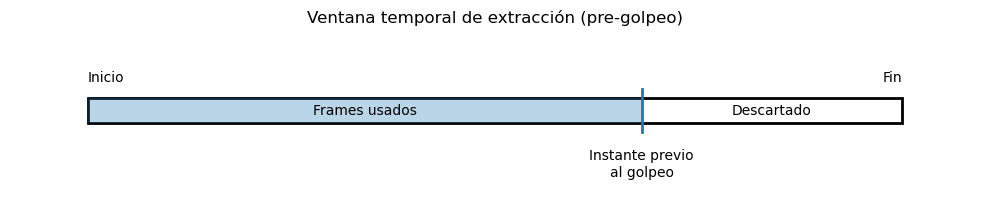

In [121]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_figura_C_timeline(save_path=None, title="Ventana temporal de extracción (pre-golpeo)"):
    fig, ax = plt.subplots(figsize=(10, 2.2))
    ax.set_ylim(0, 1)
    ax.set_xlim(0, 1)
    ax.axis("off")

    # Barra completa del vídeo
    ax.add_patch(patches.Rectangle((0.08, 0.45), 0.84, 0.15, fill=False, linewidth=2))
    ax.text(0.08, 0.68, "Inicio", ha="left", va="bottom", fontsize=10)
    ax.text(0.92, 0.68, "Fin", ha="right", va="bottom", fontsize=10)

    # Corte en t_golpeo (posición ilustrativa)
    t_cut = 0.68  # solo ilustrativo
    ax.add_patch(patches.Rectangle((0.08, 0.45), 0.84 * t_cut, 0.15, fill=True, alpha=0.3))
    ax.text(0.08 + 0.84 * t_cut, 0.30, "Instante previo\nal golpeo", ha="center", va="top", fontsize=10)
    ax.plot([0.08 + 0.84 * t_cut, 0.08 + 0.84 * t_cut], [0.40, 0.65], linewidth=2)

    ax.text(0.08 + 0.84 * (t_cut/2), 0.53, "Frames usados", ha="center", va="center", fontsize=10)
    ax.text(0.08 + 0.84 * (t_cut + (1-t_cut)/2), 0.53, "Descartado", ha="center", va="center", fontsize=10)

    ax.set_title(title, fontsize=12)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# Ejemplo:
plot_figura_C_timeline(save_path="figura_C_pregolpeo.png")


# Resultados: Fases V1 a V3

En estas secciones se generan tablas por arquitectura a partir de los CSV de resultados.  
La lógica es siempre la misma:

1. Se cargan los CSV de una fase (o conjunto de fases).
2. Para cada `target_embedding`, se selecciona la **mejor ejecución** según `best_f1` (F1 macro).
3. Se imprimen tablas LaTeX con:
   - Métricas principales (F1 macro, accuracy, pérdidas).
   - F1 por clase (izquierda / centro / derecha), para ver el efecto del desbalance.
   - Hiperparámetros relevantes, para poder reproducir el mejor experimento.

Esto permite comparar embeddings de forma homogénea dentro de cada arquitectura, y ver cómo cambia el rendimiento entre fases.


## MLP
### Tabla MLP (V1–V2): mejores resultados por embedding

Esta tabla selecciona, para cada `target_embedding`, la ejecución con mayor `best_f1` dentro de los CSV de V1–V2.  
Es útil para ver qué embeddings dan mejores picos de rendimiento en fase exploratoria y qué configuraciones los producen.

Interpretación recomendada:
- `best_f1` (F1 macro) es el criterio principal.
- `best_f1_per_class` permite comprobar si el modelo está ignorando la clase minoritaria (centro).
- `test_loss` ayuda a detectar casos en los que el F1 sube pero la generalización es inestable.


In [122]:
import pandas as pd
import ast

csv_v1 = "results/MLP/mlp_results_v1_Optuna.csv"
csv_v2 = "results/MLP/mlp_results_v2.csv"

df_all = pd.concat(
    [pd.read_csv(csv_v1), pd.read_csv(csv_v2)],
    ignore_index=True
)

if "model" in df_all.columns:
    df_all = df_all[df_all["model"] == "MLP"].copy()

metric_cols = [
    "best_f1",
    "best_f1_per_class",
    "best_accuracy",
    "test_loss_best_state",
    "train_loss_best_state",
    "best_epoch",
    "epochs_trained",
]

best_rows = []
for emb, g in df_all.groupby("target_embedding"):
    idx = g["best_f1"].idxmax()
    best_rows.append(g.loc[idx, ["target_embedding"] + metric_cols])

best = pd.DataFrame(best_rows).sort_values("best_f1", ascending=False)

def fmt_f1c(v):
    try:
        vals = ast.literal_eval(str(v))
        return "/".join(f"{float(x):.3f}" for x in vals)
    except Exception:
        return str(v)

best["best_f1_per_class"] = best["best_f1_per_class"].apply(fmt_f1c)
# print(best)
# print("\n \n")


USE_ADJUSTBOX = True   

lines = []
lines.append(r"\begin{table}[!htbp]")
lines.append(r"\caption{Mejor resultado por \textit{embedding} para la MLP (fases V1 y V2).}")
lines.append(r"\label{tab:mlp_best_per_embedding_v1v2}")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(r"\setlength{\tabcolsep}{3pt}")
lines.append(r"\renewcommand{\arraystretch}{1.05}")

if USE_ADJUSTBOX:
    lines.append(r"\begin{adjustbox}{max width=\textwidth}")

lines.append(r"\begin{tabular}{|l|c|c|c|c|c|c|}")
lines.append(r"\hline")
lines.append(
    r"Embedding & F1 & F1 per class & Acc & Loss$_\text{test}$ & Loss$_\text{train}$ & Epoch / Epochs$_\text{trained}$\\\hline"
)


for _, r in best.iterrows():
    emb = str(r["target_embedding"]).replace("_", r"\_").replace(".csv", "")
    f1 = f"{r['best_f1']:.3f}"
    f1c = r["best_f1_per_class"]
    acc = f"{r['best_accuracy']:.3f}"
    ltst = f"{r['test_loss_best_state']:.3f}"
    ltr = f"{r['train_loss_best_state']:.3f}"
    ep = f"{int(r['best_epoch'])}/{int(r['epochs_trained'])}"

    lines.append(f"{emb} & {f1} & {f1c} & {acc} & {ltst} & {ltr} & {ep} \\\\ \\hline")

lines.append(r"\end{tabular}")

if USE_ADJUSTBOX:
    lines.append(r"\end{adjustbox}")

lines.append(r"\end{table}")

print("\n".join(lines))


\begin{table}[!htbp]
\caption{Mejor resultado por \textit{embedding} para la MLP (fases V1 y V2).}
\label{tab:mlp_best_per_embedding_v1v2}
\centering
\small
\setlength{\tabcolsep}{3pt}
\renewcommand{\arraystretch}{1.05}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{|l|c|c|c|c|c|c|}
\hline
Embedding & F1 & F1 per class & Acc & Loss$_\text{test}$ & Loss$_\text{train}$ & Epoch / Epochs$_\text{trained}$\\\hline
baseline\_OUMVLP & 0.697 & 0.667/0.667/0.757 & 0.705 & 1.577 & 0.102 & 108/115 \\ \hline
gln\_phase1 & 0.692 & 0.700/0.727/0.649 & 0.682 & 1.224 & 0.455 & 254/467 \\ \hline
gaitpart\_OUMVLP & 0.665 & 0.714/0.615/0.667 & 0.682 & 1.151 & 0.521 & 29/93 \\ \hline
gln\_phase2 & 0.644 & 0.700/0.600/0.632 & 0.659 & 1.770 & 0.390 & 489/583 \\ \hline
baseline\_CASIAB & 0.642 & 0.681/0.600/0.645 & 0.659 & 1.970 & 0.218 & 392/506 \\ \hline
gaitgl & 0.639 & 0.619/0.727/0.571 & 0.614 & 1.702 & 0.112 & 111/131 \\ \hline
gaitpart\_GREW & 0.639 & 0.711/0.600/0.606 & 0.659 & 1.650 & 0.103 

### Tabla MLP (V3): mejores resultados por embedding con entrenamiento robusto

Esta tabla repite el mismo criterio (mejor `best_f1` por embedding), pero usando los experimentos de V3.  
Aquí interesa comparar con V1–V2 para ver si el “entrenar mejor” (y no solo “explorar más”) mejora estabilidad y equilibrio por clase.


In [123]:
import pandas as pd
import ast

csv_v3 = "results/MLP/mlp_results_v3.csv"

df = pd.read_csv(csv_v3)

if "model" in df.columns:
    df = df[df["model"] == "MLP"].copy()

metric_cols = [
    "best_f1",
    "best_f1_per_class",
    "best_accuracy",
    "test_loss_best_state",
    "train_loss_best_state",
    "best_epoch",
    "epochs_trained",
]

# por si faltara alguna columna en ese CSV
metric_cols = [c for c in metric_cols if c in df.columns]

best_rows = []
for emb, g in df.groupby("target_embedding"):
    idx = g["best_f1"].idxmax()
    best_rows.append(g.loc[idx, ["target_embedding"] + metric_cols])

best = pd.DataFrame(best_rows).sort_values("best_f1", ascending=False)

def fmt_f1c(v):
    try:
        vals = ast.literal_eval(str(v))
        return "/".join(f"{float(x):.3f}" for x in vals)
    except Exception:
        return str(v)

if "best_f1_per_class" in best.columns:
    best["best_f1_per_class"] = best["best_f1_per_class"].apply(fmt_f1c)



USE_ADJUSTBOX = True  

lines = []
lines.append(r"\begin{table}[!htbp]")
lines.append(r"\caption{Mejor resultado por \textit{embedding} para la MLP (fase V3).}")
lines.append(r"\label{tab:mlp_best_per_embedding_v3}")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(r"\setlength{\tabcolsep}{3pt}")
lines.append(r"\renewcommand{\arraystretch}{1.05}")

if USE_ADJUSTBOX:
    lines.append(r"\begin{adjustbox}{max width=\textwidth}")

lines.append(r"\begin{tabular}{|l|c|c|c|c|c|c|}")
lines.append(r"\hline")
lines.append(
    r"Embedding & F1 & F1 per class & Acc & Loss$_\text{test}$ & Loss$_\text{train}$ & Epoch / Epochs$_\text{trained}$\\\hline"
)


for _, r in best.iterrows():
    emb = str(r["target_embedding"]).replace("_", r"\_").replace(".csv", "")

    f1  = f"{float(r['best_f1']):.3f}" if "best_f1" in best.columns and pd.notna(r["best_f1"]) else "-"
    f1c = r["best_f1_per_class"] if "best_f1_per_class" in best.columns else "-"
    acc = f"{float(r['best_accuracy']):.3f}" if "best_accuracy" in best.columns and pd.notna(r["best_accuracy"]) else "-"

    ltst = f"{float(r['test_loss_best_state']):.3f}" if "test_loss_best_state" in best.columns and pd.notna(r["test_loss_best_state"]) else "-"
    ltr  = f"{float(r['train_loss_best_state']):.3f}" if "train_loss_best_state" in best.columns and pd.notna(r["train_loss_best_state"]) else "-"

    ep_best = int(r["best_epoch"]) if "best_epoch" in best.columns and pd.notna(r["best_epoch"]) else None
    ep_tot  = int(r["epochs_trained"]) if "epochs_trained" in best.columns and pd.notna(r["epochs_trained"]) else None
    ep = f"{ep_best}/{ep_tot}" if ep_best is not None and ep_tot is not None else "-"

    lines.append(f"{emb} & {f1} & {f1c} & {acc} & {ltst} & {ltr} & {ep} \\\\ \\hline")

lines.append(r"\end{tabular}")

if USE_ADJUSTBOX:
    lines.append(r"\end{adjustbox}")

lines.append(r"\end{table}")

print("\n".join(lines))


\begin{table}[!htbp]
\caption{Mejor resultado por \textit{embedding} para la MLP (fase V3).}
\label{tab:mlp_best_per_embedding_v3}
\centering
\small
\setlength{\tabcolsep}{3pt}
\renewcommand{\arraystretch}{1.05}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{|l|c|c|c|c|c|c|}
\hline
Embedding & F1 & F1 per class & Acc & Loss$_\text{test}$ & Loss$_\text{train}$ & Epoch / Epochs$_\text{trained}$\\\hline
baseline\_OUMVLP & 0.694 & 0.667/0.750/0.667 & 0.682 & 1.177 & 0.209 & 144/598 \\ \hline
gln\_phase1 & 0.693 & 0.667/0.727/0.684 & 0.682 & 1.139 & 0.191 & 707/957 \\ \hline
gaitpart\_GREW & 0.661 & 0.723/0.727/0.533 & 0.659 & 1.270 & 0.149 & 81/373 \\ \hline
gaitgl\_OUMVLP & 0.637 & 0.696/0.714/0.500 & 0.636 & 1.706 & 0.150 & 1615/1805 \\ \hline
gaitpart\_OUMVLP & 0.633 & 0.698/0.533/0.667 & 0.659 & 1.422 & 0.206 & 226/777 \\ \hline
gaitgl\_GREW\_BNNeck & 0.627 & 0.708/0.533/0.640 & 0.659 & 1.260 & 0.140 & 99/249 \\ \hline
baseline\_CASIAB & 0.623 & 0.698/0.600/0.571 & 0.636 & 1.6

### Tabla MLP (V1–V3): mejor configuración global por embedding

En lugar de separar por fase, esta tabla busca el mejor experimento por embedding considerando V1, V2 y V3 en conjunto.  
Sirve para identificar el “mejor caso” alcanzado por la MLP para cada representación y tener una referencia directa para comparaciones entre arquitecturas.


In [124]:
import pandas as pd
import ast
import numpy as np

csv_v1 = "results/MLP/mlp_results_v1_Optuna.csv"
csv_v2 = "results/MLP/mlp_results_v2.csv"
csv_v3 = "results/MLP/mlp_results_v3.csv"  

df_all = pd.concat([pd.read_csv(csv_v1), pd.read_csv(csv_v2), pd.read_csv(csv_v3)], ignore_index=True)

if "model" in df_all.columns:
    df_all = df_all[df_all["model"] == "MLP"].copy()


best_rows = []
for emb, g in df_all.groupby("target_embedding"):
    idx_best = g["best_f1"].idxmax()
    best_rows.append(g.loc[idx_best])

best = (
    pd.DataFrame(best_rows)
    .sort_values("best_f1", ascending=False)
    .reset_index(drop=True)
)


def fmt_pca(r):
    if bool(r.get("use_pca", False)) is False:
        return "No"
    try:
        return f'{float(r.get("pca_frac", 0.0)):.1f}'
    except:
        return "Sí"

best["PCA"] = best.apply(fmt_pca, axis=1)


cfg_cols = [
    "target_embedding",
    "pooling", "norm", "PCA",
    "hidden_layers",
    "activation",
    "optimizer", "learning_rate",
    "batch_size", "dropout_rate", "id"
]
cfg_cols = [c for c in cfg_cols if c in best.columns]
tab_cfg = best[cfg_cols].copy()


if "learning_rate" in tab_cfg.columns:
    tab_cfg["learning_rate"] = tab_cfg["learning_rate"].apply(lambda x: f"{float(x):.0e}")
if "dropout_rate" in tab_cfg.columns:
    tab_cfg["dropout_rate"] = tab_cfg["dropout_rate"].astype(float).round(2)

def tex_escape(s):
    return str(s).replace("_", r"\_")


USE_ADJUSTBOX = True 

lines = []
lines.append(r"\begin{table}[!htbp]")
lines.append(r"\caption{Configuración asociada al mejor resultado por \textit{embedding} para la MLP (V1, V2 y V3).}")
lines.append(r"\label{tab:mlp_best_config_per_embedding_v1v2v3}")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(r"\setlength{\tabcolsep}{3pt}")
lines.append(r"\renewcommand{\arraystretch}{1.05}")

if USE_ADJUSTBOX:
    lines.append(r"\begin{adjustbox}{max width=\textwidth}")

lines.append(r"\begin{tabular}{|l|c|c|c|c|c|c|c|c|c|c|}")
lines.append(r"\hline")
lines.append(r"Embedding & Pool & Norm & PCA & Dims & Act & Opt & LR & Batch & Drop & ID\\\hline")

for _, r in tab_cfg.iterrows():
    emb = tex_escape(str(r.get("target_embedding", "")).replace(".csv", ""))

    pool  = tex_escape(r.get("pooling", "-"))
    norm  = tex_escape(r.get("norm", "-"))
    pca   = tex_escape(r.get("PCA", "-"))
    dims  = tex_escape(r.get("hidden_layers", "-"))
    act   = tex_escape(r.get("activation", "-"))
    opt   = tex_escape(r.get("optimizer", "-"))
    lr    = tex_escape(r.get("learning_rate", "-"))
    batch = str(int(r.get("batch_size"))) if "batch_size" in tab_cfg.columns and pd.notna(r.get("batch_size")) else "-"
    drop  = tex_escape(r.get("dropout_rate", "-"))
    rid   = tex_escape(r.get("id", "-"))

    lines.append(f"{emb} & {pool} & {norm} & {pca} & {dims} & {act} & {opt} & {lr} & {batch} & {drop} & {rid} \\\\ \\hline")

lines.append(r"\end{tabular}")

if USE_ADJUSTBOX:
    lines.append(r"\end{adjustbox}")

lines.append(r"\end{table}")

print("\n".join(lines))


\begin{table}[!htbp]
\caption{Configuración asociada al mejor resultado por \textit{embedding} para la MLP (V1, V2 y V3).}
\label{tab:mlp_best_config_per_embedding_v1v2v3}
\centering
\small
\setlength{\tabcolsep}{3pt}
\renewcommand{\arraystretch}{1.05}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{|l|c|c|c|c|c|c|c|c|c|c|}
\hline
Embedding & Pool & Norm & PCA & Dims & Act & Opt & LR & Batch & Drop & ID\\\hline
baseline\_OUMVLP & mean & minmax & 0.8 & [768, 512, 256] & silu & Adam & 2e-04 & 64 & 0.4 & 223 \\ \hline
gln\_phase1 & mean & minmax & No & [1024, 768, 384, 192] & leakyrelu & SGD & 2e-03 & 80 & 0.55 & 1481 \\ \hline
gaitpart\_OUMVLP & mean & minmax & 0.8 & [768, 768, 768, 768] & gelu & AdamW & 3e-04 & 128 & 0.4 & 398 \\ \hline
gaitpart\_GREW & mean & minmax & 0.7 & [1024, 768, 512] & gelu & AdamW & 2e-04 & 96 & 0.4 & 241 \\ \hline
gln\_phase2 & max & L2 & 0.7 & [1280, 960, 640, 320, 160] & gelu & Adam & 1e-04 & 96 & 0.3 & 1469 \\ \hline
baseline\_CASIAB & mean & minmax

## LSTM
### Tabla LSTM (V1–V2): mejores resultados por embedding

Esta tabla selecciona al igual que en la MLP, para cada `target_embedding`, la ejecución con mayor `best_f1` dentro de los CSV de V1–V2.  
Es útil para ver qué embeddings dan mejores picos de rendimiento en fase exploratoria y qué configuraciones los producen.

Interpretación recomendada:
- `best_f1` (F1 macro) es el criterio principal.
- `best_f1_per_class` permite comprobar si el modelo está ignorando la clase minoritaria (centro).
- `test_loss` ayuda a detectar casos en los que el F1 sube pero la generalización es inestable.


In [125]:
import pandas as pd
import ast

csv_v1 = "results/LSTM/lstm_results_v1_Optuna.csv"
csv_v2 = "results/LSTM/lstm_results_v2.csv"

df_v1 = pd.read_csv(csv_v1)
df_v2 = pd.read_csv(csv_v2)
df_all = pd.concat([df_v1, df_v2], ignore_index=True)

if "model" in df_all.columns:
    df_all = df_all[df_all["model"] == "LSTM"].copy()

group_cols = ["target_embedding"]
metric_cols = [
    "best_f1",
    "best_f1_per_class",
    "best_accuracy",
    "test_loss_best_state",
    "train_loss_best_state",
    "best_epoch",
    "epochs_trained",
]

best_rows = []
for emb, g in df_all.groupby("target_embedding"):
    idx_best = g["best_f1"].idxmax()
    best_rows.append(g.loc[idx_best, group_cols + metric_cols])

best_per_emb = pd.DataFrame(best_rows).sort_values(
    "best_f1", ascending=False
).reset_index(drop=True)

def fmt_f1c(v):
    try:
        vals = ast.literal_eval(str(v))
        return "/".join(f"{float(x):.3f}" for x in vals)
    except Exception:
        return str(v)

best_per_emb["best_f1_per_class"] = best_per_emb["best_f1_per_class"].apply(fmt_f1c)


USE_ADJUSTBOX = True

lines = []
lines.append(r"\begin{table}[!htbp]")
lines.append(r"\caption{Mejor resultado por \textit{embedding} para la LSTM (fases V1 y V2).}")
lines.append(r"\label{tab:lstm_best_per_embedding_v1v2}")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(r"\setlength{\tabcolsep}{3pt}")
lines.append(r"\renewcommand{\arraystretch}{1.05}")

if USE_ADJUSTBOX:
    lines.append(r"\begin{adjustbox}{max width=\textwidth}")

lines.append(r"\begin{tabular}{|l|c|c|c|c|c|c|}")
lines.append(r"\hline")
lines.append(
    r"Embedding & F1 & F1 per class & Acc & Loss$_\text{test}$ & Loss$_\text{train}$ & Epoch / Epochs$_\text{trained}$\\\hline"
)

for _, r in best_per_emb.iterrows():
    emb = str(r["target_embedding"]).replace("_", r"\_").replace(".csv", "")
    f1 = f"{r['best_f1']:.3f}"
    f1c = r["best_f1_per_class"]
    acc = f"{r['best_accuracy']:.3f}"
    ltst = f"{r['test_loss_best_state']:.3f}"
    ltr  = f"{r['train_loss_best_state']:.3f}"
    ep   = f"{int(r['best_epoch'])}/{int(r['epochs_trained'])}"

    lines.append(f"{emb} & {f1} & {f1c} & {acc} & {ltst} & {ltr} & {ep} \\\\ \\hline")

lines.append(r"\end{tabular}")

if USE_ADJUSTBOX:
    lines.append(r"\end{adjustbox}")

lines.append(r"\end{table}")

print("\n".join(lines))


\begin{table}[!htbp]
\caption{Mejor resultado por \textit{embedding} para la LSTM (fases V1 y V2).}
\label{tab:lstm_best_per_embedding_v1v2}
\centering
\small
\setlength{\tabcolsep}{3pt}
\renewcommand{\arraystretch}{1.05}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{|l|c|c|c|c|c|c|}
\hline
Embedding & F1 & F1 per class & Acc & Loss$_\text{test}$ & Loss$_\text{train}$ & Epoch / Epochs$_\text{trained}$\\\hline
gln\_phase1 & 0.731 & 0.737/0.750/0.706 & 0.727 & 1.882 & 0.037 & 82/83 \\ \hline
gaitpart\_OUMVLP & 0.678 & 0.683/0.667/0.686 & 0.682 & 1.173 & 0.685 & 226/618 \\ \hline
gaitpart\_GREW & 0.656 & 0.773/0.615/0.581 & 0.682 & 1.058 & 0.555 & 375/457 \\ \hline
gaitgl\_GREW & 0.655 & 0.739/0.600/0.625 & 0.682 & 1.433 & 0.189 & 296/380 \\ \hline
baseline\_OUMVLP & 0.635 & 0.750/0.444/0.710 & 0.705 & 1.283 & 0.479 & 173/283 \\ \hline
gaitgl & 0.623 & 0.737/0.500/0.632 & 0.659 & 1.963 & 0.094 & 191/203 \\ \hline
gln\_phase2 & 0.605 & 0.634/0.667/0.514 & 0.591 & 1.030 & 0.723 & 

### Tabla LSTM (V3): mejores resultados por embedding con entrenamiento robusto

Esta tabla repite el mismo criterio (mejor `best_f1` por embedding), pero usando los experimentos de V3.  
Aquí interesa comparar con V1–V2 para ver si el “entrenar mejor” (y no solo “explorar más”) mejora estabilidad y equilibrio por clase.


In [126]:
import pandas as pd
import ast

csv_v3 = "results/LSTM/lstm_results_v3.csv"

df_v3 = pd.read_csv(csv_v3)

if "model" in df_v3.columns:
    df_v3 = df_v3[df_v3["model"] == "LSTM"].copy()

group_cols = ["target_embedding"]
metric_cols = [
    "best_f1",
    "best_f1_per_class",
    "best_accuracy",
    "test_loss_best_state",
    "train_loss_best_state",
    "best_epoch",
    "epochs_trained",
]

best_rows = []
for emb, g in df_v3.groupby("target_embedding"):
    idx_best = g["best_f1"].idxmax()
    best_rows.append(g.loc[idx_best, group_cols + metric_cols])

best_per_emb_v3 = (
    pd.DataFrame(best_rows)
    .sort_values("best_f1", ascending=False)
    .reset_index(drop=True)
)

def fmt_f1c(v):
    try:
        vals = ast.literal_eval(str(v))
        return "/".join(f"{float(x):.3f}" for x in vals)
    except Exception:
        return str(v)

best_per_emb_v3["best_f1_per_class"] = best_per_emb_v3["best_f1_per_class"].apply(fmt_f1c)


USE_ADJUSTBOX = True

lines = []
lines.append(r"\begin{table}[!htbp]")
lines.append(r"\caption{Mejor resultado por \textit{embedding} para la LSTM (fase V3).}")
lines.append(r"\label{tab:lstm_best_per_embedding_v3}")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(r"\setlength{\tabcolsep}{3pt}")
lines.append(r"\renewcommand{\arraystretch}{1.05}")

if USE_ADJUSTBOX:
    lines.append(r"\begin{adjustbox}{max width=\textwidth}")

lines.append(r"\begin{tabular}{|l|c|c|c|c|c|c|}")
lines.append(r"\hline")
lines.append(
    r"Embedding & F1 & F1 per class & Acc & Loss$_\text{test}$ & Loss$_\text{train}$ & Epoch / Epochs$_\text{trained}$\\\hline"
)

for _, r in best_per_emb_v3.iterrows():
    emb = str(r["target_embedding"]).replace("_", r"\_").replace(".csv", "")
    f1 = f"{r['best_f1']:.3f}"
    f1c = r["best_f1_per_class"]
    acc = f"{r['best_accuracy']:.3f}"
    ltst = f"{r['test_loss_best_state']:.3f}"
    ltr  = f"{r['train_loss_best_state']:.3f}"
    ep   = f"{int(r['best_epoch'])}/{int(r['epochs_trained'])}"

    lines.append(f"{emb} & {f1} & {f1c} & {acc} & {ltst} & {ltr} & {ep} \\\\ \\hline")

lines.append(r"\end{tabular}")

if USE_ADJUSTBOX:
    lines.append(r"\end{adjustbox}")

lines.append(r"\end{table}")

print("\n".join(lines))


\begin{table}[!htbp]
\caption{Mejor resultado por \textit{embedding} para la LSTM (fase V3).}
\label{tab:lstm_best_per_embedding_v3}
\centering
\small
\setlength{\tabcolsep}{3pt}
\renewcommand{\arraystretch}{1.05}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{|l|c|c|c|c|c|c|}
\hline
Embedding & F1 & F1 per class & Acc & Loss$_\text{test}$ & Loss$_\text{train}$ & Epoch / Epochs$_\text{trained}$\\\hline
gln\_phase1 & 0.734 & 0.762/0.667/0.774 & 0.750 & 1.090 & 0.160 & 86/242 \\ \hline
gaitpart\_OUMVLP & 0.692 & 0.700/0.727/0.649 & 0.682 & 0.923 & 0.608 & 342/735 \\ \hline
gaitgl\_GREW & 0.633 & 0.650/0.625/0.625 & 0.636 & 1.668 & 0.218 & 70/111 \\ \hline
baseline\_OUMVLP & 0.631 & 0.682/0.545/0.667 & 0.659 & 1.160 & 0.171 & 151/188 \\ \hline
baseline\_CASIAB & 0.614 & 0.615/0.615/0.611 & 0.614 & 1.890 & 0.243 & 208/255 \\ \hline
gln\_phase2 & 0.611 & 0.682/0.545/0.606 & 0.636 & 1.386 & 0.154 & 139/176 \\ \hline
gaitgl\_GREW\_BNNeck & 0.592 & 0.619/0.600/0.556 & 0.591 & 1.174 & 

### Tabla LSTM (V1–V3): mejor configuración global por embedding

En lugar de separar por fase, esta tabla busca el mejor experimento por embedding considerando V1, V2 y V3 en conjunto.  
Sirve para identificar el “mejor caso” alcanzado por la LSTM para cada representación y tener una referencia directa para comparaciones entre arquitecturas.


In [127]:
import pandas as pd

csv_v1 = "results/LSTM/lstm_results_v1_Optuna.csv"
csv_v2 = "results/LSTM/lstm_results_v2.csv"
csv_v3 = "results/LSTM/lstm_results_v3.csv"

df_all = pd.concat([pd.read_csv(csv_v1), pd.read_csv(csv_v2), pd.read_csv(csv_v3)], ignore_index=True)

if "model" in df_all.columns:
    df_all = df_all[df_all["model"] == "LSTM"].copy()

best_rows = []
for emb, g in df_all.groupby("target_embedding"):
    idx_best = g["best_f1"].idxmax()
    best_rows.append(g.loc[idx_best])

best = (
    pd.DataFrame(best_rows)
    .sort_values("best_f1", ascending=False)
    .reset_index(drop=True)
)

cfg_cols = [
    "target_embedding",
    "layer_sizes",          # principal
    "bidirectional",
    "pooling",
    "native_mode",          # clave: nativo vs modular
    "norm_post_lstm",       # LayerNorm global tras LSTM
    "fc_hidden",            # head
    "activation",           # afecta si fc_hidden != None
    "norm",                 # etiqueta/decisión guardada en CSV
    "optimizer",
    "learning_rate",
    "batch_size",
    "dropout",
    "id",
]
cfg_cols = [c for c in cfg_cols if c in best.columns]
tab_cfg = best[cfg_cols].copy()

def fmt_bool(x):
    if pd.isna(x):
        return "-"
    return "Sí" if bool(x) else "No"

if "learning_rate" in tab_cfg.columns:
    tab_cfg["learning_rate"] = tab_cfg["learning_rate"].apply(lambda x: f"{float(x):.0e}" if pd.notna(x) else "-")
if "dropout" in tab_cfg.columns:
    tab_cfg["dropout"] = tab_cfg["dropout"].apply(lambda x: f"{float(x):.2f}" if pd.notna(x) else "-")

for bcol in ["bidirectional", "native_mode", "norm_post_lstm"]:
    if bcol in tab_cfg.columns:
        tab_cfg[bcol] = tab_cfg[bcol].apply(fmt_bool)

def tex_escape(s):
    return str(s).replace("_", r"\_")


USE_ADJUSTBOX = True   

lines = []
lines.append(r"\begin{table}[!htbp]")
lines.append(r"\caption{Configuración asociada al mejor resultado por \textit{embedding} para la LSTM (V1, V2 y V3).}")
lines.append(r"\label{tab:lstm_best_config_per_embedding_v1v2v3}")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(r"\setlength{\tabcolsep}{3pt}")
lines.append(r"\renewcommand{\arraystretch}{1.05}")

if USE_ADJUSTBOX:
    lines.append(r"\begin{adjustbox}{max width=\textwidth}")

lines.append(r"\begin{tabular}{|l|c|c|c|c|c|c|c|c|c|c|c|}")
lines.append(r"\hline")
lines.append(r"Embedding & Dims & Bi & Pool & Native & PostNorm & FC & Act & Norm & Opt & LR & ID\\\hline")

for _, r in tab_cfg.iterrows():
    emb = tex_escape(str(r.get("target_embedding", "")).replace(".csv", ""))

    dims     = tex_escape(r.get("layer_sizes", "-"))
    bi       = tex_escape(r.get("bidirectional", "-"))
    pool     = tex_escape(r.get("pooling", "-"))
    native   = tex_escape(r.get("native_mode", "-"))
    postnorm = tex_escape(r.get("norm_post_lstm", "-"))
    fc       = tex_escape(r.get("fc_hidden", "-"))
    act      = tex_escape(r.get("activation", "-"))
    norm     = tex_escape(r.get("norm", "-"))
    opt      = tex_escape(r.get("optimizer", "-"))
    lr       = tex_escape(r.get("learning_rate", "-"))
    mid      = tex_escape(r.get("id", "-"))

    lines.append(f"{emb} & {dims} & {bi} & {pool} & {native} & {postnorm} & {fc} & {act} & {norm} & {opt} & {lr} & {mid} \\\\ \\hline")

lines.append(r"\end{tabular}")

if USE_ADJUSTBOX:
    lines.append(r"\end{adjustbox}")

lines.append(r"\end{table}")

print("\n".join(lines))


\begin{table}[!htbp]
\caption{Configuración asociada al mejor resultado por \textit{embedding} para la LSTM (V1, V2 y V3).}
\label{tab:lstm_best_config_per_embedding_v1v2v3}
\centering
\small
\setlength{\tabcolsep}{3pt}
\renewcommand{\arraystretch}{1.05}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{|l|c|c|c|c|c|c|c|c|c|c|c|}
\hline
Embedding & Dims & Bi & Pool & Native & PostNorm & FC & Act & Norm & Opt & LR & ID\\\hline
gln\_phase1 & [448] & No & last & Sí & Sí & 1024.0 & silu & L2 & Adam & 1e-03 & 155 \\ \hline
gaitpart\_OUMVLP & [288, 576] & No & last & No & No & 128.0 & relu & minmax & RMSprop & 4e-04 & 1256 \\ \hline
gaitpart\_GREW & [768, 640, 512] & No & max & No & Sí & 768.0 & relu & minmax & AdamW & 2e-05 & 46 \\ \hline
gaitgl\_GREW & [192] & Sí & mean & Sí & No & 128.0 & relu & L2 & AdamW & 3e-04 & 615 \\ \hline
baseline\_OUMVLP & [512, 256, 128, 64] & Sí & last & No & No & 768.0 & elu & nan & SGD & 1e-03 & 1523 \\ \hline
gaitgl & [896, 768, 640, 512] & No & attent

## TCN
### Tabla TCN (V1–V2): mejores resultados por embedding

Esta tabla selecciona al igual que en la MLP y LSTM, para cada `target_embedding`, la ejecución con mayor `best_f1` dentro de los CSV de V1–V2.  
Es útil para ver qué embeddings dan mejores picos de rendimiento en fase exploratoria y qué configuraciones los producen.

Interpretación recomendada:
- `best_f1` (F1 macro) es el criterio principal.
- `best_f1_per_class` permite comprobar si el modelo está ignorando la clase minoritaria (centro).
- `test_loss` ayuda a detectar casos en los que el F1 sube pero la generalización es inestable.


In [128]:
import pandas as pd
import ast

csv_tcn_v1 = "results/TCN/tcn_results_v1_Optuna.csv"
csv_tcn_v2 = "results/TCN/tcn_results_v2.csv"

df_v1 = pd.read_csv(csv_tcn_v1)
df_v2 = pd.read_csv(csv_tcn_v2)
df_all = pd.concat([df_v1, df_v2], ignore_index=True)

if "model" in df_all.columns:
    df_all = df_all[df_all["model"] == "TCN"].copy()

group_cols = ["target_embedding"]
metric_cols = [
    "best_f1",
    "best_f1_per_class",
    "best_accuracy",
    "test_loss_best_state",
    "train_loss_best_state",
    "best_epoch",
    "epochs_trained",
]

best_rows = []
for emb, g in df_all.groupby("target_embedding"):
    idx_best = g["best_f1"].idxmax()
    best_rows.append(g.loc[idx_best, group_cols + metric_cols])

best_per_emb = (
    pd.DataFrame(best_rows)
    .sort_values("best_f1", ascending=False)
    .reset_index(drop=True)
)

def fmt_f1c(v):
    try:
        vals = ast.literal_eval(str(v))
        return "/".join(f"{float(x):.3f}" for x in vals)
    except Exception:
        return str(v)

best_per_emb["best_f1_per_class"] = best_per_emb["best_f1_per_class"].apply(fmt_f1c)

USE_ADJUSTBOX = True

lines = []
lines.append(r"\begin{table}[!htbp]")
lines.append(r"\caption{Mejor resultado por \textit{embedding} para la TCN (fases V1 y V2).}")
lines.append(r"\label{tab:tcn_best_per_embedding_v1v2}")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(r"\setlength{\tabcolsep}{3pt}")
lines.append(r"\renewcommand{\arraystretch}{1.05}")

if USE_ADJUSTBOX:
    lines.append(r"\begin{adjustbox}{max width=\textwidth}")

lines.append(r"\begin{tabular}{|l|c|c|c|c|c|c|}")
lines.append(r"\hline")
lines.append(
    r"Embedding & F1 & F1 per class & Acc & Loss$_\text{test}$ & Loss$_\text{train}$ & Epoch / Epochs$_\text{trained}$\\\hline"
)

for _, r in best_per_emb.iterrows():
    emb  = str(r["target_embedding"]).replace("_", r"\_").replace(".csv", "")
    f1   = f"{r['best_f1']:.3f}"
    f1c  = r["best_f1_per_class"]
    acc  = f"{r['best_accuracy']:.3f}"
    ltst = f"{r['test_loss_best_state']:.3f}"
    ltr  = f"{r['train_loss_best_state']:.3f}"
    ep   = f"{int(r['best_epoch'])}/{int(r['epochs_trained'])}"

    lines.append(f"{emb} & {f1} & {f1c} & {acc} & {ltst} & {ltr} & {ep} \\\\ \\hline")

lines.append(r"\end{tabular}")

if USE_ADJUSTBOX:
    lines.append(r"\end{adjustbox}")

lines.append(r"\end{table}")

print("\n".join(lines))


\begin{table}[!htbp]
\caption{Mejor resultado por \textit{embedding} para la TCN (fases V1 y V2).}
\label{tab:tcn_best_per_embedding_v1v2}
\centering
\small
\setlength{\tabcolsep}{3pt}
\renewcommand{\arraystretch}{1.05}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{|l|c|c|c|c|c|c|}
\hline
Embedding & F1 & F1 per class & Acc & Loss$_\text{test}$ & Loss$_\text{train}$ & Epoch / Epochs$_\text{trained}$\\\hline
gln\_phase1 & 0.716 & 0.667/0.833/0.649 & 0.682 & 0.908 & 0.253 & 436/536 \\ \hline
gaitpart\_OUMVLP & 0.674 & 0.629/0.727/0.667 & 0.659 & 1.065 & 0.579 & 512/639 \\ \hline
gln\_phase2 & 0.658 & 0.700/0.667/0.606 & 0.659 & 1.308 & 0.107 & 100/105 \\ \hline
gaitset\_OUMVLP & 0.648 & 0.711/0.545/0.688 & 0.682 & 1.630 & 0.095 & 124/140 \\ \hline
gaitpart\_GREW & 0.624 & 0.595/0.667/0.611 & 0.614 & 2.169 & 0.176 & 153/173 \\ \hline
baseline\_OUMVLP & 0.623 & 0.571/0.600/0.698 & 0.636 & 1.035 & 0.419 & 66/99 \\ \hline
baseline\_CASIAB & 0.620 & 0.683/0.571/0.606 & 0.636 & 1.602

### Tabla TCN (V3): mejores resultados por embedding con entrenamiento robusto

Esta tabla repite el mismo criterio que la anterior (mejor `best_f1` por embedding), pero usando los experimentos de V3.  
Aquí interesa comparar con V1–V2 para ver si el “entrenar mejor” (y no solo “explorar más”) mejora estabilidad y equilibrio por clase.


In [129]:
import pandas as pd
import ast

csv_tcn_v3 = "results/TCN/tcn_results_v3.csv"

df_v3 = pd.read_csv(csv_tcn_v3)

if "model" in df_v3.columns:
    df_v3 = df_v3[df_v3["model"] == "TCN"].copy()

group_cols = ["target_embedding"]
metric_cols = [
    "best_f1",
    "best_f1_per_class",
    "best_accuracy",
    "test_loss_best_state",
    "train_loss_best_state",
    "best_epoch",
    "epochs_trained",
]

best_rows = []
for emb, g in df_v3.groupby("target_embedding"):
    idx_best = g["best_f1"].idxmax()
    best_rows.append(g.loc[idx_best, group_cols + metric_cols])

best_per_emb_v3 = (
    pd.DataFrame(best_rows)
    .sort_values("best_f1", ascending=False)
    .reset_index(drop=True)
)

def fmt_f1c(v):
    try:
        vals = ast.literal_eval(str(v))
        return "/".join(f"{float(x):.3f}" for x in vals)
    except Exception:
        return str(v)

best_per_emb_v3["best_f1_per_class"] = best_per_emb_v3["best_f1_per_class"].apply(fmt_f1c)

USE_ADJUSTBOX = True

lines = []
lines.append(r"\begin{table}[!htbp]")
lines.append(r"\caption{Mejor resultado por \textit{embedding} para la TCN (fase V3).}")
lines.append(r"\label{tab:tcn_best_per_embedding_v3}")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(r"\setlength{\tabcolsep}{3pt}")
lines.append(r"\renewcommand{\arraystretch}{1.05}")

if USE_ADJUSTBOX:
    lines.append(r"\begin{adjustbox}{max width=\textwidth}")

# 7 columnas como MLP base
lines.append(r"\begin{tabular}{|l|c|c|c|c|c|c|}")
lines.append(r"\hline")
lines.append(
    r"Embedding & F1 & F1 per class & Acc & Loss$_\text{test}$ & Loss$_\text{train}$ & Epoch / Epochs$_\text{trained}$\\\hline"
)

for _, r in best_per_emb_v3.iterrows():
    emb  = str(r["target_embedding"]).replace("_", r"\_").replace(".csv", "")
    f1   = f"{r['best_f1']:.3f}"
    f1c  = r["best_f1_per_class"]
    acc  = f"{r['best_accuracy']:.3f}"
    ltst = f"{r['test_loss_best_state']:.3f}"
    ltr  = f"{r['train_loss_best_state']:.3f}"
    ep   = f"{int(r['best_epoch'])}/{int(r['epochs_trained'])}"

    lines.append(f"{emb} & {f1} & {f1c} & {acc} & {ltst} & {ltr} & {ep} \\\\ \\hline")

lines.append(r"\end{tabular}")

if USE_ADJUSTBOX:
    lines.append(r"\end{adjustbox}")

lines.append(r"\end{table}")

print("\n".join(lines))


\begin{table}[!htbp]
\caption{Mejor resultado por \textit{embedding} para la TCN (fase V3).}
\label{tab:tcn_best_per_embedding_v3}
\centering
\small
\setlength{\tabcolsep}{3pt}
\renewcommand{\arraystretch}{1.05}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{|l|c|c|c|c|c|c|}
\hline
Embedding & F1 & F1 per class & Acc & Loss$_\text{test}$ & Loss$_\text{train}$ & Epoch / Epochs$_\text{trained}$\\\hline
gln\_phase2 & 0.750 & 0.732/0.833/0.686 & 0.727 & 0.962 & 0.315 & 19/263 \\ \hline
gln\_phase1 & 0.670 & 0.735/0.714/0.560 & 0.682 & 1.104 & 0.172 & 508/1329 \\ \hline
gaitpart\_OUMVLP & 0.666 & 0.783/0.571/0.643 & 0.705 & 0.982 & 0.142 & 709/778 \\ \hline
gaitpart\_GREW & 0.665 & 0.732/0.615/0.647 & 0.682 & 0.995 & 0.393 & 189/670 \\ \hline
baseline\_OUMVLP & 0.659 & 0.727/0.500/0.750 & 0.705 & 1.126 & 0.140 & 232/306 \\ \hline
gaitgl\_OUMVLP & 0.635 & 0.756/0.444/0.706 & 0.705 & 1.020 & 0.146 & 381/705 \\ \hline
gaitgl\_GREW & 0.633 & 0.667/0.545/0.686 & 0.659 & 1.001 & 0.143 & 

### Tabla TCN (V1–V3): mejor configuración global por embedding

En lugar de separar por fase, esta tabla busca el mejor experimento por embedding considerando V1, V2 y V3 en conjunto.  
Sirve para identificar el “mejor caso” alcanzado por TCN para cada representación y tener una referencia directa para comparaciones entre arquitecturas.


In [130]:
import pandas as pd
import ast
import numpy as np

csv_v1 = "results/TCN/tcn_results_v1_Optuna.csv"
csv_v2 = "results/TCN/tcn_results_v2.csv"
csv_v3 = "results/TCN/tcn_results_v3.csv"

df_all = pd.concat(
    [pd.read_csv(csv_v1), pd.read_csv(csv_v2), pd.read_csv(csv_v3)],
    ignore_index=True
)

if "model" in df_all.columns:
    df_all = df_all[df_all["model"] == "TCN"].copy()

# --- top-1 por embedding (máximo best_f1) ---
best_rows = []
for emb, g in df_all.groupby("target_embedding"):
    idx_best = g["best_f1"].idxmax()
    best_rows.append(g.loc[idx_best])

best = (
    pd.DataFrame(best_rows)
    .sort_values("best_f1", ascending=False)
    .reset_index(drop=True)
)

cfg_cols = [
    "target_embedding",
    "pooling",
    "channels",
    "dilations",
    "kernel_size",
    "convs_per_block",
    "dropout",
    "ln_block_end",
    "use_weight_norm",
    "wn_on_skip",
    "activation",
    "optimizer",
    "learning_rate",
    "id",
]
tab_cfg = best[cfg_cols].copy()

def fmt_bool(x):
    return "Sí" if bool(x) else "No"

def fmt_listlike(x):
    s = str(x).strip()
    if s.startswith("[") and s.endswith("]"):
        try:
            return str(ast.literal_eval(s))
        except:
            return s
    return s

tab_cfg["channels"] = tab_cfg["channels"].apply(fmt_listlike)
tab_cfg["dilations"] = tab_cfg["dilations"].apply(fmt_listlike)
tab_cfg["ln_block_end"] = tab_cfg["ln_block_end"].apply(fmt_bool)
tab_cfg["use_weight_norm"] = tab_cfg["use_weight_norm"].apply(fmt_bool)
tab_cfg["wn_on_skip"] = tab_cfg["wn_on_skip"].apply(fmt_bool)
tab_cfg["learning_rate"] = tab_cfg["learning_rate"].apply(lambda x: f"{float(x):.0e}" if str(x).replace(".","",1).isdigit() else x)
tab_cfg["dropout"] = tab_cfg["dropout"].apply(lambda x: f"{float(x):.2f}" if str(x).replace(".","",1).isdigit() else fmt_listlike(x))

def esc(x):
    return str(x).replace("_", r"\_").replace(".csv", "")

USE_ADJUSTBOX = True

lines = []
lines.append(r"\begin{table}[!htbp]")
lines.append(r"\caption{Configuración asociada al mejor resultado por \textit{embedding} para la TCN (V1, V2 y V3).}")
lines.append(r"\label{tab:tcn_best_config_per_embedding_v1v2v3}")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(r"\setlength{\tabcolsep}{3pt}")
lines.append(r"\renewcommand{\arraystretch}{1.05}")

if USE_ADJUSTBOX:
    lines.append(r"\begin{adjustbox}{max width=\textwidth}")

lines.append(r"\begin{tabular}{|l|c|c|c|c|c|c|c|c|c|c|c|c|}")
lines.append(r"\hline")
lines.append(r"Embedding & Pool & Channels & Dilations & K & Convs & LN & WN & SkipWN & Act & Opt & LR & ID\\\hline")

for _, r in tab_cfg.iterrows():
    emb  = esc(r["target_embedding"])
    pool = esc(r["pooling"])
    ch   = esc(r["channels"])
    dil  = esc(r["dilations"])
    k    = esc(r["kernel_size"])
    conv = esc(r["convs_per_block"])
    ln   = esc(r["ln_block_end"])
    wn   = esc(r["use_weight_norm"])
    sk   = esc(r["wn_on_skip"])
    act  = esc(r["activation"])
    opt  = esc(r["optimizer"])
    lr   = esc(r["learning_rate"])
    mid  = esc(r["id"])

    lines.append(f"{emb} & {pool} & {ch} & {dil} & {k} & {conv} & {ln} & {wn} & {sk} & {act} & {opt} & {lr} & {mid} \\\\ \\hline")

lines.append(r"\end{tabular}")

if USE_ADJUSTBOX:
    lines.append(r"\end{adjustbox}")

lines.append(r"\end{table}")

print("\n".join(lines))


\begin{table}[!htbp]
\caption{Configuración asociada al mejor resultado por \textit{embedding} para la TCN (V1, V2 y V3).}
\label{tab:tcn_best_config_per_embedding_v1v2v3}
\centering
\small
\setlength{\tabcolsep}{3pt}
\renewcommand{\arraystretch}{1.05}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{|l|c|c|c|c|c|c|c|c|c|c|c|c|}
\hline
Embedding & Pool & Channels & Dilations & K & Convs & LN & WN & SkipWN & Act & Opt & LR & ID\\\hline
gln\_phase2 & attention & [512, 512, 512, 1024] & [1, 2, 4, 6] & 5 & 2 & Sí & Sí & Sí & leakyrelu & AdamW & 1e-04 & 1053 \\ \hline
gln\_phase1 & attention & [896, 768, 640] & [3, 6, 9] & 2 & 2 & Sí & No & No & leakyrelu & Adam & 1e-05 & 181 \\ \hline
gaitpart\_OUMVLP & last & [256, 256, 384, 384] & [1, 2, 2, 4] & 7 & 3 & Sí & Sí & Sí & gelu & AdamW & 2e-04 & 372 \\ \hline
gaitpart\_GREW & attention & [896, 768, 640] & [3, 6, 9] & 2 & 2 & Sí & No & No & leakyrelu & Adam & 1e-05 & 33 \\ \hline
baseline\_OUMVLP & attention & [384, 384, 384, 512] & [1,

## Transformer
### Tabla Transformer (V1–V2): mejores resultados por embedding

Esta tabla selecciona al igual que en la MLP, para cada `target_embedding`, la ejecución con mayor `best_f1` dentro de los CSV de V1–V2.  
Es útil para ver qué embeddings dan mejores picos de rendimiento en fase exploratoria y qué configuraciones los producen.

Interpretación recomendada:
- `best_f1` (F1 macro) es el criterio principal.
- `best_f1_per_class` permite comprobar si el modelo está ignorando la clase minoritaria (centro).
- `test_loss` ayuda a detectar casos en los que el F1 sube pero la generalización es inestable.


In [131]:
import pandas as pd
import ast

csv_tr_v1 = "results/Transformer/transformer_results_v1_Optuna.csv"
csv_tr_v2 = "results/Transformer/transformer_results_v2.csv"

df_v1 = pd.read_csv(csv_tr_v1)
df_v2 = pd.read_csv(csv_tr_v2)
df_all = pd.concat([df_v1, df_v2], ignore_index=True)

if "model" in df_all.columns:
    df_all = df_all[df_all["model"] == "Transformer"].copy()

group_cols = ["target_embedding"]
metric_cols = [
    "best_f1",
    "best_f1_per_class",
    "best_accuracy",
    "test_loss_best_state",
    "train_loss_best_state",
    "best_epoch",
    "epochs_trained",
]

best_rows = []
for emb, g in df_all.groupby("target_embedding"):
    idx_best = g["best_f1"].idxmax()
    best_rows.append(g.loc[idx_best, group_cols + metric_cols])

best_per_emb = (
    pd.DataFrame(best_rows)
    .sort_values("best_f1", ascending=False)
    .reset_index(drop=True)
)

def fmt_f1c(v):
    try:
        vals = ast.literal_eval(str(v))
        return "/".join(f"{float(x):.3f}" for x in vals)
    except Exception:
        return str(v)

best_per_emb["best_f1_per_class"] = best_per_emb["best_f1_per_class"].apply(fmt_f1c)

USE_ADJUSTBOX = True

lines = []
lines.append(r"\begin{table}[!htbp]")
lines.append(r"\caption{Mejor resultado por \textit{embedding} para el Transformer (fases V1 y V2).}")
lines.append(r"\label{tab:tr_best_per_embedding_v1v2}")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(r"\setlength{\tabcolsep}{3pt}")
lines.append(r"\renewcommand{\arraystretch}{1.05}")

if USE_ADJUSTBOX:
    lines.append(r"\begin{adjustbox}{max width=\textwidth}")

lines.append(r"\begin{tabular}{|l|c|c|c|c|c|c|}")
lines.append(r"\hline")
lines.append(
    r"Embedding & F1 & F1 per class & Acc & Loss$_\text{test}$ & Loss$_\text{train}$ & Epoch / Epochs$_\text{trained}$\\\hline"
)

for _, r in best_per_emb.iterrows():
    emb  = str(r["target_embedding"]).replace("_", r"\_").replace(".csv", "")
    f1   = f"{r['best_f1']:.3f}"
    f1c  = r["best_f1_per_class"]
    acc  = f"{r['best_accuracy']:.3f}"
    ltst = f"{r['test_loss_best_state']:.3f}"
    ltr  = f"{r['train_loss_best_state']:.3f}"
    ep   = f"{int(r['best_epoch'])}/{int(r['epochs_trained'])}"

    lines.append(f"{emb} & {f1} & {f1c} & {acc} & {ltst} & {ltr} & {ep} \\\\ \\hline")

lines.append(r"\end{tabular}")

if USE_ADJUSTBOX:
    lines.append(r"\end{adjustbox}")

lines.append(r"\end{table}")

print("\n".join(lines))


\begin{table}[!htbp]
\caption{Mejor resultado por \textit{embedding} para el Transformer (fases V1 y V2).}
\label{tab:tr_best_per_embedding_v1v2}
\centering
\small
\setlength{\tabcolsep}{3pt}
\renewcommand{\arraystretch}{1.05}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{|l|c|c|c|c|c|c|}
\hline
Embedding & F1 & F1 per class & Acc & Loss$_\text{test}$ & Loss$_\text{train}$ & Epoch / Epochs$_\text{trained}$\\\hline
gaitpart\_OUMVLP & 0.683 & 0.650/0.769/0.629 & 0.659 & 1.349 & 0.507 & 347/589 \\ \hline
baseline\_OUMVLP & 0.678 & 0.723/0.600/0.710 & 0.705 & 1.436 & 0.333 & 612/669 \\ \hline
gaitset\_GREW & 0.638 & 0.681/0.714/0.519 & 0.636 & 1.854 & 0.208 & 334/392 \\ \hline
gln\_phase2 & 0.634 & 0.739/0.600/0.562 & 0.659 & 0.980 & 0.608 & 248/397 \\ \hline
gaitset & 0.614 & 0.737/0.533/0.571 & 0.636 & 2.050 & 0.100 & 589/593 \\ \hline
gaitgl\_GREW\_BNNeck & 0.612 & 0.537/0.769/0.529 & 0.568 & 2.099 & 0.291 & 993/1292 \\ \hline
gln\_phase1 & 0.609 & 0.723/0.462/0.643 & 0.659 & 

### Tabla Transformer (V3): mejores resultados por embedding con entrenamiento robusto

Esta tabla repite el mismo criterio (mejor `best_f1` por embedding), pero usando los experimentos de V3.  
Aquí interesa comparar con V1–V2 para ver si el “entrenar mejor” (y no solo “explorar más”) mejora estabilidad y equilibrio por clase.


In [132]:
import pandas as pd
import ast

csv_tr_v3 = "results/Transformer/transformer_results_v3.csv"

df_v3 = pd.read_csv(csv_tr_v3)

if "model" in df_v3.columns:
    df_v3 = df_v3[df_v3["model"] == "Transformer"].copy()

group_cols = ["target_embedding"]
metric_cols = [
    "best_f1",
    "best_f1_per_class",
    "best_accuracy",
    "test_loss_best_state",
    "train_loss_best_state",
    "best_epoch",
    "epochs_trained",
]

best_rows = []
for emb, g in df_v3.groupby("target_embedding"):
    idx_best = g["best_f1"].idxmax()
    best_rows.append(g.loc[idx_best, group_cols + metric_cols])

best_per_emb_v3 = (
    pd.DataFrame(best_rows)
    .sort_values("best_f1", ascending=False)
    .reset_index(drop=True)
)

def fmt_f1c(v):
    try:
        vals = ast.literal_eval(str(v))
        return "/".join(f"{float(x):.3f}" for x in vals)
    except Exception:
        return str(v)

best_per_emb_v3["best_f1_per_class"] = best_per_emb_v3["best_f1_per_class"].apply(fmt_f1c)



USE_ADJUSTBOX = True

lines = []
lines.append(r"\begin{table}[!htbp]")
lines.append(r"\caption{Mejor resultado por \textit{embedding} para el Transformer (fase V3).}")
lines.append(r"\label{tab:tr_best_per_embedding_v3}")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(r"\setlength{\tabcolsep}{3pt}")
lines.append(r"\renewcommand{\arraystretch}{1.05}")

if USE_ADJUSTBOX:
    lines.append(r"\begin{adjustbox}{max width=\textwidth}")

lines.append(r"\begin{tabular}{|l|c|c|c|c|c|c|}")
lines.append(r"\hline")
lines.append(
    r"Embedding & F1 & F1 per class & Acc & Loss$_\text{test}$ & Loss$_\text{train}$ & Epoch / Epochs$_\text{trained}$\\\hline"
)

for _, r in best_per_emb_v3.iterrows():
    emb  = str(r["target_embedding"]).replace("_", r"\_").replace(".csv", "")
    f1   = f"{r['best_f1']:.3f}"
    f1c  = r["best_f1_per_class"]
    acc  = f"{r['best_accuracy']:.3f}"
    ltst = f"{r['test_loss_best_state']:.3f}"
    ltr  = f"{r['train_loss_best_state']:.3f}"
    ep   = f"{int(r['best_epoch'])}/{int(r['epochs_trained'])}"

    lines.append(f"{emb} & {f1} & {f1c} & {acc} & {ltst} & {ltr} & {ep} \\\\ \\hline")

lines.append(r"\end{tabular}")

if USE_ADJUSTBOX:
    lines.append(r"\end{adjustbox}")

lines.append(r"\end{table}")

print("\n".join(lines))


\begin{table}[!htbp]
\caption{Mejor resultado por \textit{embedding} para el Transformer (fase V3).}
\label{tab:tr_best_per_embedding_v3}
\centering
\small
\setlength{\tabcolsep}{3pt}
\renewcommand{\arraystretch}{1.05}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{|l|c|c|c|c|c|c|}
\hline
Embedding & F1 & F1 per class & Acc & Loss$_\text{test}$ & Loss$_\text{train}$ & Epoch / Epochs$_\text{trained}$\\\hline
gaitset & 0.648 & 0.700/0.615/0.629 & 0.659 & 1.225 & 0.205 & 702/980 \\ \hline
gaitpart\_OUMVLP & 0.648 & 0.756/0.429/0.759 & 0.705 & 1.376 & 0.267 & 678/761 \\ \hline
baseline\_OUMVLP & 0.641 & 0.667/0.571/0.686 & 0.659 & 1.444 & 0.224 & 1263/1328 \\ \hline
gaitgl\_GREW & 0.631 & 0.682/0.545/0.667 & 0.659 & 1.604 & 0.198 & 960/1026 \\ \hline
gaitpart\_GREW & 0.630 & 0.750/0.533/0.606 & 0.659 & 1.115 & 0.466 & 1785/2191 \\ \hline
gaitgl & 0.623 & 0.526/0.727/0.615 & 0.591 & 1.780 & 0.159 & 68/80 \\ \hline
gaitgl\_OUMVLP & 0.612 & 0.682/0.533/0.621 & 0.636 & 1.803 & 0.221 &

### Tabla Transformer (V1–V3): mejor configuración global por embedding

En lugar de separar por fase, esta tabla busca el mejor experimento por embedding considerando V1, V2 y V3 en conjunto.  
Sirve para identificar el “mejor caso” alcanzado por el Transformer para cada representación y tener una referencia directa para comparaciones entre arquitecturas.


In [133]:
import pandas as pd
import ast
import numpy as np

csv_v1 = "results/Transformer/transformer_results_v1_Optuna.csv"
csv_v2 = "results/Transformer/transformer_results_v2.csv"
csv_v3 = "results/Transformer/transformer_results_v3.csv"

df_all = pd.concat(
    [pd.read_csv(csv_v1), pd.read_csv(csv_v2), pd.read_csv(csv_v3)],
    ignore_index=True
)

if "model" in df_all.columns:
    df_all = df_all[df_all["model"].astype(str).str.lower() == "transformer"].copy()

# --- top-1 por embedding (máximo best_f1) ---
best_rows = []
for emb, g in df_all.groupby("target_embedding"):
    idx_best = g["best_f1"].idxmax()
    best_rows.append(g.loc[idx_best])

best = (
    pd.DataFrame(best_rows)
    .sort_values("best_f1", ascending=False)
    .reset_index(drop=True)
)

cfg_cols = [
    "target_embedding",
    "model_dims",
    "num_heads",
    "num_layers",
    "dim_feedforward",
    "dropout",
    "norm_type",
    "pos_encoding",
    "pooling",
    "use_cls_token",
    "optimizer",
    "lr",
    "clip_grad_norm",
    "id",
]
tab_cfg = best[cfg_cols].copy()

def fmt_bool(x):
    return "Sí" if bool(x) else "No"

def fmt_listlike(x):
    s = str(x).strip()
    if s.startswith("[") and s.endswith("]"):
        try:
            return str(ast.literal_eval(s))
        except:
            return s
    return s

tab_cfg["model_dims"] = tab_cfg["model_dims"].apply(fmt_listlike)
tab_cfg["use_cls_token"] = tab_cfg["use_cls_token"].apply(fmt_bool)
tab_cfg["lr"] = tab_cfg["lr"].apply(lambda x: f"{float(x):.0e}")
tab_cfg["dropout"] = tab_cfg["dropout"].apply(lambda x: f"{float(x):.2f}")
tab_cfg["clip_grad_norm"] = tab_cfg["clip_grad_norm"].apply(lambda x: f"{float(x):.2f}")

def esc(x):
    return str(x).replace("_", r"\_").replace(".csv", "")

USE_ADJUSTBOX = True

lines = []
lines.append(r"\begin{table}[!htbp]")
lines.append(r"\caption{Configuración asociada al mejor resultado por \textit{embedding} para el Transformer (V1, V2 y V3).}")
lines.append(r"\label{tab:transformer_best_config_per_embedding_v1v2v3}")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(r"\setlength{\tabcolsep}{3pt}")
lines.append(r"\renewcommand{\arraystretch}{1.05}")

if USE_ADJUSTBOX:
    lines.append(r"\begin{adjustbox}{max width=\textwidth}")

lines.append(r"\begin{tabular}{|l|c|c|c|c|c|c|c|c|c|c|c|}")
lines.append(r"\hline")
lines.append(r"Embedding & Dims & Heads & FFN & Drop & Norm & Pos & Pool & CLS & Opt & LR & ID\\\hline")

for _, r in tab_cfg.iterrows():
    emb   = esc(r["target_embedding"])
    dims  = esc(r["model_dims"])
    heads = esc(r["num_heads"])
    ffn   = esc(r["dim_feedforward"])
    drop  = esc(r["dropout"])
    ntyp  = esc(r["norm_type"])
    pos   = esc(r["pos_encoding"])
    pool  = esc(r["pooling"])
    cls   = esc(r["use_cls_token"])
    opt   = esc(r["optimizer"])
    lr    = esc(r["lr"])
    mid   = esc(r["id"])

    lines.append(f"{emb} & {dims} & {heads} & {ffn} & {drop} & {ntyp} & {pos} & {pool} & {cls} & {opt} & {lr} & {mid} \\\\ \\hline")

lines.append(r"\end{tabular}")

if USE_ADJUSTBOX:
    lines.append(r"\end{adjustbox}")

lines.append(r"\end{table}")

print("\n".join(lines))


\begin{table}[!htbp]
\caption{Configuración asociada al mejor resultado por \textit{embedding} para el Transformer (V1, V2 y V3).}
\label{tab:transformer_best_config_per_embedding_v1v2v3}
\centering
\small
\setlength{\tabcolsep}{3pt}
\renewcommand{\arraystretch}{1.05}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{|l|c|c|c|c|c|c|c|c|c|c|c|}
\hline
Embedding & Dims & Heads & FFN & Drop & Norm & Pos & Pool & CLS & Opt & LR & ID\\\hline
gaitpart\_OUMVLP & [512, 512, 512] & 8 & 1024 & 0.10 & prenorm & learned & cls & Sí & AdamW & 7e-05 & 437 \\ \hline
baseline\_OUMVLP & [256, 384, 512] & 16 & 768 & 0.10 & prenorm & learned & cls & Sí & AdamW & 1e-04 & 392 \\ \hline
gaitset & [896, 640, 384] & 16 & 1024 & 0.05 & prenorm & sinusoidal & cls & Sí & RMSprop & 5e-05 & 1088 \\ \hline
gaitset\_GREW & [768, 640] & 4 & 256 & 0.10 & postnorm & learned & mean & No & AdamW & 5e-05 & 10 \\ \hline
gln\_phase2 & [256, 512] & 8 & 512 & 0.00 & prenorm & sinusoidal & mean & No & AdamW & 2e-05 & 923 

# Resultados Fase V4 (fusión de embeddings)

En V4 se evalúan entradas fusionadas para comprobar si combinar representaciones aporta señal adicional o reduce ruido.  
La tabla de resumen compara, por arquitectura, el mejor F1 alcanzado en:
- baseline (V1–V2),
- reentreno robusto (V3),
- y variantes fusionadas (concat, mean y versiones reduced).

Lectura recomendada:
- comparar el mejor valor de V4 frente a la referencia (V3) para ver si la fusión aporta mejora real,
- interpretar resultados junto al coste/estabilidad (según el comportamiento observado en entrenamientos).


### V4: mejor configuración por embedding derivado (por arquitectura)

En esta celda se genera una tabla (en LaTeX) que resume, para una arquitectura concreta (variable `ARCH`) y un tipo de entrada de V4 (variable `EXPERIMENT`: `concat`, `mean` o `reduced`), cuál es el **mejor resultado obtenido para cada embedding derivado**.

El procedimiento es el siguiente:

1. **Carga del CSV de V4** correspondiente (por ejemplo, `transformer_results_v4_mean.csv`) y verificación de consistencia entre `EXPERIMENT` y el nombre del fichero para evitar errores de selección.
2. **Agrupación por `target_embedding`**: cada nombre de embedding derivado (p. ej., una combinación concreta en V4) puede tener varias filas en el CSV porque se han probado distintas configuraciones/hyperparámetros.
3. Para cada embedding derivado, se selecciona la fila con **máximo `best_f1` (F1 macro)**, de forma que la tabla compare “el mejor caso” de cada embedding en igualdad de condiciones.
4. Se formatea `best_f1_per_class` para mostrar el F1 por clase como `izquierda/centro/derecha` (con 3 decimales), lo que permite ver rápidamente si el rendimiento está equilibrado o si alguna clase (normalmente `centro`) se queda atrás.
5. Por último, se imprimen métricas clave del mejor estado:  
   - `best_f1` (F1 macro) como criterio principal  
   - `best_accuracy` como referencia de acierto global  
   - `test_loss_best_state` y `train_loss_best_state` para detectar sobreajuste  
   - `best_epoch / epochs_trained` para contextualizar en qué punto se alcanzó el mejor modelo

La tabla resultante permite identificar qué embeddings derivados de V4 aportan más señal para la arquitectura seleccionada y, además, facilita comparar si la mejora viene de un rendimiento más equilibrado entre clases o de un aumento concentrado en una sola dirección.


In [134]:
import pandas as pd
import ast
import re


ARCH = "Transformer"  # "MLP" | "LSTM" | "TCN" | "Transformer"
EXPERIMENT = "mean"  # "concat" | "mean" | "reduced"

CSV_PATH = "results/Transformer/transformer_results_v4_mean.csv"  # cambia según EXPERIMENT

if EXPERIMENT != CSV_PATH.split("_")[-1].replace(".csv",""):
    raise ValueError("EXPERIMENT no coincide con el CSV cargado")


df_all = pd.read_csv(CSV_PATH, low_memory=False)

metric_cols = [
    "best_f1",
    "best_f1_per_class",
    "best_accuracy",
    "test_loss_best_state",
    "train_loss_best_state",
    "best_epoch",
    "epochs_trained",
]

has_model = "model" in df_all.columns
cols_take = (["model"] if has_model else []) + metric_cols


best_rows = []
for emb, g in df_all.groupby("target_embedding"):
    idx = g["best_f1"].idxmax()
    best_rows.append(g.loc[idx, ["target_embedding"] + cols_take])

best = pd.DataFrame(best_rows).sort_values("best_f1", ascending=False)

# Formatear F1 por clase
def fmt_f1c(v):
    try:
        vals = ast.literal_eval(str(v))
        return "/".join(f"{float(x):.3f}" for x in vals)
    except Exception:
        return str(v)

best["best_f1_per_class"] = best["best_f1_per_class"].apply(fmt_f1c)


if EXPERIMENT == "concat":
    exp_name = "CONCAT"
    exp_label = "concat"
elif EXPERIMENT == "mean":
    exp_name = "MEAN"
    exp_label = "mean"
elif EXPERIMENT == "reduced":
    exp_name = "REDUCED"
    exp_label = "reduced"
else:
    raise ValueError("EXPERIMENT debe ser 'concat', 'mean' o 'reduced'")


USE_ADJUSTBOX = True
arch_lower = ARCH.lower()

caption = rf"Mejor resultado por \textit{{embedding}} derivado ({exp_name}) en la fase V4 para {ARCH}."
label   = rf"tab:v4_{arch_lower}_best_per_embedding_{exp_label}"

lines = []
lines.append(r"\begin{table}[!htbp]")
lines.append(rf"\caption{{{caption}}}")
lines.append(rf"\label{{{label}}}")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(r"\setlength{\tabcolsep}{4pt}")
lines.append(r"\renewcommand{\arraystretch}{1.15}")

if USE_ADJUSTBOX:
    lines.append(r"\begin{adjustbox}{max width=\textwidth}")

if has_model:
    lines.append(r"\begin{tabular}{|l|c|c|c|c|c|c|c|}")
    lines.append(r"\hline")
    lines.append(r"Embedding & Modelo & F1 & F1 por clases & Acc & Loss$_\text{test}$ & Loss$_\text{train}$ & Epoca / Epocas$_\text{tot}$\\\hline")
else:
    lines.append(r"\begin{tabular}{|l|c|c|c|c|c|c|}")
    lines.append(r"\hline")
    lines.append(r"Embedding & F1 & F1 por clases & Acc & Loss$_\text{test}$ & Loss$_\text{train}$ & Epoca / Epocas$_\text{tot}$\\\hline")

for _, r in best.iterrows():

    raw = str(r["target_embedding"]).replace(".csv", "")
    raw = re.sub(r"_\d+steps", "", raw)   # elimina _XXsteps quitarlo cuando ya se tengan todos los embeddings limpios REVISAR
    emb = raw.replace("_", r"\_")

    # emb = str(r["target_embedding"]).replace("_", r"\_").replace(".csv", "")
    f1 = f"{float(r['best_f1']):.3f}"
    f1c = r["best_f1_per_class"]
    acc = f"{float(r['best_accuracy']):.3f}"
    ltst = f"{float(r['test_loss_best_state']):.3f}"
    ltr = f"{float(r['train_loss_best_state']):.3f}"
    ep = f"{int(r['best_epoch'])}/{int(r['epochs_trained'])}"

    if has_model:
        mdl = str(r["model"]).replace("_", r"\_")
        lines.append(f"{emb} & {mdl} & {f1} & {f1c} & {acc} & {ltst} & {ltr} & {ep} \\\\ \\hline")
    else:
        lines.append(f"{emb} & {f1} & {f1c} & {acc} & {ltst} & {ltr} & {ep} \\\\ \\hline")

lines.append(r"\end{tabular}")

if USE_ADJUSTBOX:
    lines.append(r"\end{adjustbox}")

lines.append(r"\end{table}")

print("\n".join(lines))


\begin{table}[!htbp]
\caption{Mejor resultado por \textit{embedding} derivado (MEAN) en la fase V4 para Transformer.}
\label{tab:v4_transformer_best_per_embedding_mean}
\centering
\small
\setlength{\tabcolsep}{4pt}
\renewcommand{\arraystretch}{1.15}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{|l|c|c|c|c|c|c|c|}
\hline
Embedding & Modelo & F1 & F1 por clases & Acc & Loss$_\text{test}$ & Loss$_\text{train}$ & Epoca / Epocas$_\text{tot}$\\\hline
gaitpart\_mean & Transformer & 0.668 & 0.784/0.500/0.720 & 0.727 & 1.431 & 0.480 & 827/914 \\ \hline
gln\_mean & Transformer & 0.668 & 0.683/0.615/0.706 & 0.682 & 1.144 & 0.204 & 822/1041 \\ \hline
baseline\_mean & Transformer & 0.647 & 0.556/0.769/0.615 & 0.614 & 1.445 & 0.620 & 734/1366 \\ \hline
gaitset\_mean & Transformer & 0.614 & 0.667/0.462/0.714 & 0.659 & 1.154 & 0.742 & 489/1085 \\ \hline
gaitgl\_mean & Transformer & 0.603 & 0.632/0.444/0.732 & 0.659 & 1.409 & 0.160 & 78/96 \\ \hline
\end{tabular}
\end{adjustbox}
\end{table}


### Resumen de V4: comparación de máximos por arquitectura

Esta celda genera una tabla-resumen (en LaTeX) que compara, **para cada arquitectura**, el **máximo F1 macro (`best_f1`) alcanzado** en distintos escenarios:

- **Embeddings base (V1–V2):** mejor resultado obtenido usando embeddings “originales”, excluyendo variantes fusionadas (`_concat`, `_mean`) o combinadas.
- **Embeddings base (V3):** mejor resultado en la fase de reentreno robusto, también excluyendo variantes fusionadas.
- **Fusión por concatenación (V4):** mejor resultado entre embeddings fusionados por concatenación (filtrando por sufijo `_concat`).
- **Fusión por promedio (V4):** mejor resultado entre embeddings fusionados por promedio (filtrando por sufijo `_mean`).
- **Reducción de steps + concatenación / promedio (V4):** mejor resultado cuando primero se reduce/alinea el número de *steps* y después se aplica fusión (`_concat` o `_mean`) sobre esa versión “reduced”.

La intención de esta tabla es dar una **vista rápida de “techo de rendimiento”** por arquitectura y por tipo de entrada, para comprobar si V4 aporta mejoras claras frente a los embeddings base (V1–V3).  
Como solo se reporta el máximo, esta tabla no mide estabilidad; esa parte se analiza aparte con el experimento multi-seed.


In [135]:
import pandas as pd

BASE_V1_V2 = {
    "MLP": "results/MLP/mlp_results_v1_Optuna.csv|results/MLP/mlp_results_v2.csv",
    "LSTM": "results/LSTM/lstm_results_v1_Optuna.csv|results/LSTM/lstm_results_v2.csv",
    "TCN": "results/TCN/tcn_results_v1_Optuna.csv|results/TCN/tcn_results_v2.csv",
    "Transformer": "results/Transformer/transformer_results_v1_Optuna.csv|results/Transformer/transformer_results_v2.csv",
}
BASE_V3 = {
    "MLP": "results/MLP/mlp_results_v3.csv",
    "LSTM": "results/LSTM/lstm_results_v3.csv",
    "TCN": "results/TCN/tcn_results_v3.csv",
    "Transformer": "results/Transformer/transformer_results_v3.csv",
}
V4_CONCAT = {
    "MLP": "results/MLP/mlp_results_v4_concat.csv",
    "LSTM": "results/LSTM/lstm_results_v4_concat.csv",
    "TCN": "results/TCN/tcn_results_v4_concat.csv",
    "Transformer": "results/Transformer/transformer_results_v4_concat.csv",
}
V4_MEAN = {
    "MLP": "results/MLP/mlp_results_v4_mean.csv",
    "LSTM": "results/LSTM/lstm_results_v4_mean.csv",
    "TCN": "results/TCN/tcn_results_v4_mean.csv",
    "Transformer": "results/Transformer/transformer_results_v4_mean.csv",
}
V4_REDUCED = {
    "MLP": "results/MLP/mlp_results_v4_reduced.csv",
    "LSTM": "results/LSTM/lstm_results_v4_reduced.csv",
    "TCN": "results/TCN/tcn_results_v4_reduced.csv",
    "Transformer": "results/Transformer/transformer_results_v4_reduced.csv",
}

ARCHS = ["MLP", "LSTM", "TCN", "Transformer"]

def read_many(pipe_paths: str):
    return pd.concat([pd.read_csv(p, low_memory=False) for p in pipe_paths.split("|")], ignore_index=True)

def best_f1(df, include_tag=None, exclude_tags=None):
    df = df.copy()
    if include_tag is not None:
        df = df[df["target_embedding"].astype(str).str.contains(include_tag, na=False)]
    if exclude_tags:
        for t in exclude_tags:
            df = df[~df["target_embedding"].astype(str).str.contains(t, na=False)]
    idx = df["best_f1"].idxmax()
    return float(df.loc[idx, "best_f1"])

# --- claves internas (no “bonitas”) ---
vals = {
    "Base V1--V2": {},
    "Base V3": {},
    "V4 Concatenado": {},
    "V4 Promedio": {},
    "V4 Reducido + Concatenado": {},
    "V4 Reducido + Promedio": {},
}

for a in ARCHS:
    vals["Base V1--V2"][a] = best_f1(read_many(BASE_V1_V2[a]), exclude_tags=["_concat","_mean","COMBINED"])
    vals["Base V3"][a] = best_f1(pd.read_csv(BASE_V3[a], low_memory=False), exclude_tags=["_concat","_mean","COMBINED"])
    vals["V4 Concatenado"][a] = best_f1(pd.read_csv(V4_CONCAT[a], low_memory=False), include_tag="_concat")
    vals["V4 Promedio"][a] = best_f1(pd.read_csv(V4_MEAN[a], low_memory=False), include_tag="_mean")
    vals["V4 Reducido + Concatenado"][a] = best_f1(pd.read_csv(V4_REDUCED[a], low_memory=False), include_tag="_concat")
    vals["V4 Reducido + Promedio"][a] = best_f1(pd.read_csv(V4_REDUCED[a], low_memory=False), include_tag="_mean")

# --- nombres bonitos en el orden que quieres ---
order = [
  "Embeddings base (V1--V2)",
  "Embeddings base (V3)",
  "Fusión por concatenación (V4)",
  "Fusión por promedio (V4)",
  "Reducción de steps + concatenación (V4)",
  "Reducción de steps + promedio (V4)",
]

# --- mapping: bonito -> clave interna ---
LABELS = {
  "Embeddings base (V1--V2)": "Base V1--V2",
  "Embeddings base (V3)": "Base V3",
  "Fusión por concatenación (V4)": "V4 Concatenado",
  "Fusión por promedio (V4)": "V4 Promedio",
  "Reducción de steps + concatenación (V4)": "V4 Reducido + Concatenado",
  "Reducción de steps + promedio (V4)": "V4 Reducido + Promedio",
}

# --- LaTeX ---
USE_ADJUSTBOX = True

lines = []
lines.append(r"\begin{table}[!htbp]")
lines.append(r"\caption{Resumen V4 (F1-macro): máximo alcanzado por arquitectura.}")
lines.append(r"\label{tab:v4_summary_f1_only}")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(r"\setlength{\tabcolsep}{6pt}")
lines.append(r"\renewcommand{\arraystretch}{1.10}")

if USE_ADJUSTBOX:
    lines.append(r"\begin{adjustbox}{max width=\textwidth}")

lines.append(r"\begin{tabular}{|l|c|c|c|c|}")
lines.append(r"\hline")
lines.append(r"Experimento & MLP & LSTM & TCN & Transformer\\\hline")

for exp in order:
    k = LABELS[exp]  # clave interna real
    row = [exp] + [f"{vals[k][a]:.3f}" for a in ARCHS]
    lines.append(" & ".join(row) + r" \\ \hline")

lines.append(r"\end{tabular}")

if USE_ADJUSTBOX:
    lines.append(r"\end{adjustbox}")

lines.append(r"\end{table}")

print("\n".join(lines))


\begin{table}[!htbp]
\caption{Resumen V4 (F1-macro): máximo alcanzado por arquitectura.}
\label{tab:v4_summary_f1_only}
\centering
\small
\setlength{\tabcolsep}{6pt}
\renewcommand{\arraystretch}{1.10}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{|l|c|c|c|c|}
\hline
Experimento & MLP & LSTM & TCN & Transformer\\\hline
Embeddings base (V1--V2) & 0.697 & 0.731 & 0.716 & 0.683 \\ \hline
Embeddings base (V3) & 0.694 & 0.734 & 0.750 & 0.648 \\ \hline
Fusión por concatenación (V4) & 0.676 & 0.672 & 0.649 & 0.685 \\ \hline
Fusión por promedio (V4) & 0.768 & 0.705 & 0.704 & 0.668 \\ \hline
Reducción de steps + concatenación (V4) & 0.728 & 0.641 & 0.653 & 0.604 \\ \hline
Reducción de steps + promedio (V4) & 0.658 & 0.679 & 0.577 & 0.602 \\ \hline
\end{tabular}
\end{adjustbox}
\end{table}


# Resultados Fase V5 (selección de steps informativos)

En V5 se generan versiones recortadas de cada embedding conservando el porcentaje de *steps* más informativos (Top-30/50/70%).  
El objetivo es comprobar si existe un subconjunto de franjas corporales que concentre señal predictiva:

- Si el F1 se mantiene: se puede reducir dimensionalidad sin perder rendimiento.
- Si mejora: sugiere que eliminar *steps* ruidosos ayuda a generalizar.
- Si cae: indica que el modelo necesita información distribuida en más regiones del cuerpo.

Las tablas comparan, embedding a embedding:
- F1 original vs F1 en Top-30/50/70,
- la mejor mejora observada (Δ),
- y la variante ganadora para cada representación.


### V5: comparación entre embeddings originales y versiones Top-% (por arquitectura)

Esta celda construye automáticamente, para cada arquitectura (MLP, LSTM, TCN y Transformer), una tabla en formato LaTeX que compara el mejor rendimiento alcanzado con:

- el **embedding original** (mejor resultado encontrado en las fases V1–V3), y  
- las variantes de **V5 con selección de steps** (Top70%, Top50% y Top30%).

La idea es responder de forma directa a la pregunta de V5: *¿se puede reducir la entrada quedándonos solo con las franjas corporales más informativas sin perder rendimiento (o incluso mejorarlo)?*

Para hacerlo de manera justa, el código:
1. **Carga y concatena** los CSV de V1–V3 de cada arquitectura, y extrae para cada embedding original el **máximo `best_f1`** observado (`f1_orig`).
2. Carga los tres CSV de V5 (Top70/Top50/Top30) y, para cada variante y embedding, selecciona igualmente el **máximo `best_f1`**.
3. Normaliza los nombres de los embeddings (`normalize_embedding_name`) eliminando sufijos como `_top30%`, `_top50%`, `_top70%` (y también `_XXsteps` si aparece), para que el **matching** entre “original” y “Top-%” sea consistente.
4. Une (merge) los resultados y calcula:
   - `Best Δ`: la **mejor mejora** de las variantes Top-% respecto al original (`best_top - f1_orig`).
   - `Best variant`: qué variante (Original, Top70%, Top50% o Top30%) obtiene el mejor F1.

La tabla final queda ordenada por `Best Δ`, de manera que en las primeras filas aparecen los embeddings donde la selección de steps aporta más mejora (o donde al menos no degrada), y permite identificar rápidamente en qué casos V5 resulta beneficioso y en cuáles la reducción introduce pérdida de información.


In [136]:
import re
import pandas as pd
import numpy as np


PATHS_ORIG = {
    "MLP": [
        "results/MLP/mlp_results_v1_Optuna.csv",
        "results/MLP/mlp_results_v2.csv",
        "results/MLP/mlp_results_v3.csv",
    ],
    "LSTM": [
        "results/LSTM/lstm_results_v1_Optuna.csv",
        "results/LSTM/lstm_results_v2.csv",
        "results/LSTM/lstm_results_v3.csv",
    ],
    "TCN": [
        "results/TCN/tcn_results_v1_Optuna.csv",
        "results/TCN/tcn_results_v2.csv",
        "results/TCN/tcn_results_v3.csv",
    ],
    "Transformer": [
        "results/Transformer/transformer_results_v1_Optuna.csv",
        "results/Transformer/transformer_results_v2.csv",
        "results/Transformer/transformer_results_v3.csv",
    ],
}

PATHS_V5 = {
    "MLP": {
        "top30": "results/MLP/mlp_results_v5_top30%.csv",
        "top50": "results/MLP/mlp_results_v5_top50%.csv",
        "top70": "results/MLP/mlp_results_v5_top70%.csv",
    },
    "LSTM": {
        "top30": "results/LSTM/lstm_results_v5_top30%.csv",
        "top50": "results/LSTM/lstm_results_v5_top50%.csv",
        "top70": "results/LSTM/lstm_results_v5_top70%.csv",
    },
    "TCN": {
        "top30": "results/TCN/tcn_results_v5_top30%.csv",
        "top50": "results/TCN/tcn_results_v5_top50%.csv",
        "top70": "results/TCN/tcn_results_v5_top70%.csv",
    },
    "Transformer": {
        "top30": "results/Transformer/transformer_results_v5_top30%.csv",
        "top50": "results/Transformer/transformer_results_v5_top50%.csv",
        "top70": "results/Transformer/transformer_results_v5_top70%.csv",
    },
}

USE_ADJUSTBOX = True



def read_many(csv_list):
    dfs = [pd.read_csv(p, low_memory=False) for p in csv_list]
    return pd.concat(dfs, ignore_index=True)

def pick_metric_col(df: pd.DataFrame):
    for c in ["best_f1"]:
        if c in df.columns:
            return c
    raise ValueError("No encuentro columna de mejor f1")

def normalize_embedding_name(x: str) -> str:
    s = str(x).replace(".csv", "").strip()
    s = re.sub(r"(_\d+steps)$", "", s)
    s = re.sub(r"(_top(30|50|70)(pct|percent|%|))$", "", s, flags=re.IGNORECASE)
    s = re.sub(r"(_low(30|50|70)(pct|percent|%|))$", "", s, flags=re.IGNORECASE)
    return s

def latex_escape(s: str) -> str:
    return s.replace("_", r"\_")

def best_row_per_group(df: pd.DataFrame, group_cols, metric_col):
    idx = df.groupby(group_cols)[metric_col].idxmax()
    return df.loc[idx].copy()

def fmt(x):
    return "-" if pd.isna(x) else f"{float(x):.3f}"

# Tabla V5 por arquitectura
def make_v5_table_for_arch(arch: str, orig_csvs, v5_csvs_dict):
    # ---- ORIGINAL (V1+V2+V3) ----
    df_o = read_many(orig_csvs)
    if "model" in df_o.columns:
        df_o = df_o[df_o["model"].astype(str) == arch].copy()

    metric_o = pick_metric_col(df_o)
    df_o["emb_norm"] = df_o["target_embedding"].apply(normalize_embedding_name)

    df_o_best = best_row_per_group(df_o, ["emb_norm"], metric_o)
    df_o_best = df_o_best[["emb_norm", metric_o]].rename(columns={metric_o: "f1_orig"})

    # ---- V5 TOPS (3 CSV) ----
    top_frames = []
    for variant in ["top70", "top50", "top30"]:
        path = v5_csvs_dict.get(variant)
        if path is None:
            continue

        df_v = pd.read_csv(path, low_memory=False)
        if "model" in df_v.columns:
            df_v = df_v[df_v["model"].astype(str) == arch].copy()

        metric_v = pick_metric_col(df_v)
        df_v["emb_norm"] = df_v["target_embedding"].apply(normalize_embedding_name)

        df_v_best = best_row_per_group(df_v, ["emb_norm"], metric_v)
        df_v_best = df_v_best[["emb_norm", metric_v]].rename(columns={metric_v: "f1"})
        df_v_best["variant"] = variant
        top_frames.append(df_v_best)

    df_tops = pd.concat(top_frames, ignore_index=True) if top_frames else pd.DataFrame(columns=["emb_norm","f1","variant"])
    pivot = df_tops.pivot(index="emb_norm", columns="variant", values="f1").reset_index()
    pivot = pivot.rename(columns={"top70": "f1_top70", "top50": "f1_top50", "top30": "f1_top30"})

    # ---- merge ----
    out = df_o_best.merge(pivot, on="emb_norm", how="left")

    tops = out[["f1_top70", "f1_top50", "f1_top30"]].to_numpy(dtype=float)
    best_top = np.nanmax(tops, axis=1)
    best_top[np.isneginf(best_top)] = np.nan

    out["delta_best"] = best_top - out["f1_orig"]

    def best_variant_row(row):
        vals = {"Top70\%": row.get("f1_top70", np.nan),
                "Top50\%": row.get("f1_top50", np.nan),
                "Top30\%": row.get("f1_top30", np.nan),
                "Original": row.get("f1_orig", np.nan)}
        vals = {k: v for k, v in vals.items() if pd.notna(v)}
        if not vals:
            return "-"
        return max(vals, key=lambda k: vals[k])

    out["best_variant"] = out.apply(best_variant_row, axis=1)
    out = out.sort_values(["delta_best", "f1_orig"], ascending=[False, False]).reset_index(drop=True)


    arch_lower = arch.lower()
    caption = rf"Comparación V5 (selección de \textit{{steps}}) vs embeddings originales para {arch}."
    label = rf"tab:v5_{arch_lower}_orig_vs_topsteps"

    lines = []
    lines.append(r"\begin{table}[!htbp]")
    lines.append(rf"\caption{{{caption}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\centering")
    lines.append(r"\small")
    lines.append(r"\setlength{\tabcolsep}{4pt}")
    lines.append(r"\renewcommand{\arraystretch}{1.15}")

    if USE_ADJUSTBOX:
        lines.append(r"\begin{adjustbox}{max width=\textwidth}")

    lines.append(r"\begin{tabular}{|l|c|c|c|c|c|c|}")
    lines.append(r"\hline")
    lines.append(r"Embedding & Original F1 & Top70\% F1 & Top50\% F1 & Top30\% F1 & Best $\Delta$ & Best variant\\\hline")


    for _, r in out.iterrows():
        emb = latex_escape(str(r["emb_norm"]))

        if pd.isna(r["delta_best"]):
            delta_str = "-"
        else:
            delta_str = f"{float(r['delta_best']):+.3f}"

        line = (
            f"{emb} & {fmt(r['f1_orig'])} & {fmt(r.get('f1_top70', np.nan))} & "
            f"{fmt(r.get('f1_top50', np.nan))} & {fmt(r.get('f1_top30', np.nan))} & "
            f"{delta_str} & {r['best_variant']} \\\\ \\hline"
        )
        lines.append(line)

    lines.append(r"\end{tabular}")

    if USE_ADJUSTBOX:
        lines.append(r"\end{adjustbox}")

    lines.append(r"\end{table}")

    print("\n".join(lines))
    return out



if __name__ == "__main__":
    for arch in ["MLP", "LSTM", "TCN", "Transformer"]:
        print("\n" + "="*120)
        print(f"TABLE V5 -> {arch}")
        print("="*120 + "\n")
        make_v5_table_for_arch(
            arch=arch,
            orig_csvs=PATHS_ORIG[arch],
            v5_csvs_dict=PATHS_V5[arch],
        )



TABLE V5 -> MLP

\begin{table}[!htbp]
\caption{Comparación V5 (selección de \textit{steps}) vs embeddings originales para MLP.}
\label{tab:v5_mlp_orig_vs_topsteps}
\centering
\small
\setlength{\tabcolsep}{4pt}
\renewcommand{\arraystretch}{1.15}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{|l|c|c|c|c|c|c|}
\hline
Embedding & Original F1 & Top70\% F1 & Top50\% F1 & Top30\% F1 & Best $\Delta$ & Best variant\\\hline
gaitset & 0.579 & 0.559 & 0.575 & 0.693 & +0.114 & Top30\% \\ \hline
gaitgl\_GREW & 0.517 & 0.581 & 0.587 & 0.533 & +0.070 & Top50\% \\ \hline
gaitpart\_GREW & 0.661 & 0.611 & 0.718 & 0.642 & +0.057 & Top50\% \\ \hline
gaitpart\_OUMVLP & 0.665 & 0.659 & 0.640 & 0.694 & +0.029 & Top30\% \\ \hline
gaitset\_GREW & 0.622 & 0.626 & 0.627 & 0.646 & +0.024 & Top30\% \\ \hline
gln\_phase2 & 0.644 & 0.658 & 0.553 & 0.593 & +0.014 & Top70\% \\ \hline
baseline\_CASIAB & 0.642 & 0.605 & 0.643 & 0.653 & +0.011 & Top30\% \\ \hline
baseline\_OUMVLP & 0.697 & 0.642 & 0.706 & 0.665 

# Resúmenes de resultados

En esta parte se combinan resultados de varias arquitecturas para construir comparativas globales:
- Qué embedding funciona mejor **por arquitectura**.
- Qué arquitectura alcanza mejores valores **en promedio** y en **máximo**.
- Qué combinaciones modelo–embedding aparecen como candidatas principales antes de pasar a V4–V5.

La idea no es sustituir las tablas por arquitectura, sino aportar una vista “de alto nivel” para interpretar patrones consistentes.


### Comparativa V1–V2 vs V3 (impacto del entrenamiento robusto)

Este bloque contrasta resultados de la fase exploratoria (V1–V2) frente a la fase de reentreno robusto (V3).  
La tabla resume, por arquitectura, diferencias en:
- rendimiento medio,
- mejor rendimiento alcanzado,
- y el cambio (Δ) al pasar a V3.

Sirve para justificar experimentalmente si las técnicas de robustez mejoran realmente la generalización o simplemente cambian el comportamiento sin aportar ganancia estable.


In [137]:
import os
import pandas as pd

from src.utils.comparison_results import compare_model_results

OUT_DIR = "results/Comparisons_V1_V2_V3"

jobs = [
    ("MLP",
     ["results/MLP/mlp_results_v1_Optuna.csv", "results/MLP/mlp_results_v2.csv"],
     "results/MLP/mlp_results_v3.csv"),

    ("LSTM",
     ["results/LSTM/lstm_results_v1_Optuna.csv", "results/LSTM/lstm_results_v2.csv"],
     "results/LSTM/lstm_results_v3.csv"),

    ("TCN",
     ["results/TCN/tcn_results_v1_Optuna.csv", "results/TCN/tcn_results_v2.csv"],
     "results/TCN/tcn_results_v3.csv"),

    ("Transformer",
     ["results/Transformer/transformer_results_v1_Optuna.csv", "results/Transformer/transformer_results_v2.csv"],
     "results/Transformer/transformer_results_v3.csv"),
]

stats_paths = {}
for model, hist, v3 in jobs:
    out_stats_path, out_id_path = compare_model_results(
        model_type=model,
        historical_files=hist,
        final_file_path=v3,
        output_dir=OUT_DIR
    )
    stats_paths[model] = out_stats_path


def fmt3(x):
    try:
        return f"{float(x):.3f}".rstrip("0").rstrip(".")
    except:
        return str(x)

def clean_emb(s):
    s = str(s)
    if s.endswith(".csv"):
        s = s[:-4]
    return s.replace("_", r"\_")  # LaTeX escape

def latex_table_stats(model, csv_path, top_n=None):
    df = pd.read_csv(csv_path)

    # limpiar nombre embedding
    df["target_embedding"] = df["target_embedding"].apply(clean_emb)

    # Redondeo/formato
    for c in ["mean_f1_v1_v2","mean_f1_v3","mean_diff","max_f1_v1_v2","max_f1_v3","max_diff","std_f1_v1_v2","std_f1_v3"]:
        if c in df.columns:
            df[c] = df[c].apply(fmt3)

    # Ordenar por mejora media
    if "mean_diff" in df.columns:
        df = df.sort_values("mean_diff", ascending=False)

    if top_n is not None:
        df = df.head(top_n)

    cols = [
        "target_embedding",
        "mean_f1_v1_v2",
        "mean_f1_v3",
        "mean_diff",
        "max_f1_v1_v2",
        "max_f1_v3",
        "max_diff",
    ]
    cols = [c for c in cols if c in df.columns]

    headers_map = {
        "target_embedding": r"Embedding",
        "mean_f1_v1_v2": r"F1$_{\text{mean}}$ (V1/V2)",
        "mean_f1_v3": r"F1$_{\text{mean}}$ (V3)",
        "mean_diff": r"$\Delta$F1$_{\text{mean}}$",
        "max_f1_v1_v2": r"F1$_{\text{max}}$ (V1/V2)",
        "max_f1_v3": r"F1$_{\text{max}}$ (V3)",
        "max_diff": r"$\Delta$F1$_{\text{max}}$",
    }

    headers = [headers_map[c] for c in cols]


    USE_ADJUSTBOX = True 

    lines = []
    lines.append(r"\begin{table}[!htbp]")
    lines.append(
        rf"\caption{{Impacto de V3 en {model}: comparación V1/V2 vs V3 por \textit{{embedding}} (media y máximo sobre IDs reentrenados).}}"
    )
    lines.append(rf"\label{{tab:impacto_v3_{model.lower()}}}")
    lines.append(r"\centering")
    lines.append(r"\small")
    lines.append(r"\setlength{\tabcolsep}{3pt}")
    lines.append(r"\renewcommand{\arraystretch}{1.05}")

    if USE_ADJUSTBOX:
        lines.append(r"\begin{adjustbox}{max width=\textwidth}")


    ncols = len(cols)
    if ncols < 2:
        colfmt = r"|l|"
    else:
        colfmt = r"|l|" + "c|" * (ncols - 1)

    lines.append(rf"\begin{{tabular}}{{{colfmt}}}")
    lines.append(r"\hline")
    lines.append(" & ".join(headers) + r"\\\hline")

    for _, r in df[cols].iterrows():
        row = [str(r[c]) for c in cols]
        lines.append(" & ".join(row) + r" \\ \hline")

    lines.append(r"\end{tabular}")

    if USE_ADJUSTBOX:
        lines.append(r"\end{adjustbox}")

    lines.append(r"\end{table}")
    return "\n".join(lines)

for model, path in stats_paths.items():
    print("\n\n% ===== TABLA", model, "=====\n")
    print(latex_table_stats(model, path, top_n=None))  # o top_n=10


--- Iniciando comparación para el modelo: MLP ---
Archivos históricos cargados: 2
Archivo final cargado: mlp_results_v3.csv

--- Comparación por embedding (media, max, std de best_f1) sobre IDs coincidentes... ---
Se comparará sobre los 858 IDs únicos presentes en el archivo final (V3).
✅ Comparación estadística por embedding guardada en: results/Comparisons_V1_V2_V3\mlp_training_comparison_stats.csv

--- Comparación por ID (configuración exacta) con F1 macro y F1 por clase... ---
✅ Comparación por ID guardada en: results/Comparisons_V1_V2_V3\mlp_training_comparison_id.csv

--- Iniciando comparación para el modelo: LSTM ---
Archivos históricos cargados: 2
Archivo final cargado: lstm_results_v3.csv

--- Comparación por embedding (media, max, std de best_f1) sobre IDs coincidentes... ---
Se comparará sobre los 455 IDs únicos presentes en el archivo final (V3).
✅ Comparación estadística por embedding guardada en: results/Comparisons_V1_V2_V3\lstm_training_comparison_stats.csv

--- Compara

### Mejor resultado por arquitectura (V1–V3)

In [138]:
import pandas as pd
import ast
import numpy as np

CSV_PATHS = [
    "results/MLP/mlp_results_v1_Optuna.csv",
    "results/MLP/mlp_results_v2.csv",
    "results/MLP/mlp_results_v3.csv",
    "results/LSTM/lstm_results_v1_Optuna.csv",
    "results/LSTM/lstm_results_v2.csv",
    "results/LSTM/lstm_results_v3.csv",
    "results/TCN/tcn_results_v1_Optuna.csv",
    "results/TCN/tcn_results_v2.csv",
    "results/TCN/tcn_results_v3.csv",
    "results/Transformer/transformer_results_v1_Optuna.csv",
    "results/Transformer/transformer_results_v2.csv",
    "results/Transformer/transformer_results_v3.csv",

]

dfs = [pd.read_csv(p) for p in CSV_PATHS]
df_all = pd.concat(dfs, ignore_index=True)

df_sorted = df_all.sort_values("best_f1", ascending=False)
best_by_model_emb = (
    df_sorted
    .groupby(["model", "target_embedding"], as_index=False)
    .first()
)

def parse_f1_list(v):
    try:
        vals = ast.literal_eval(str(v))
        if isinstance(vals, (list, tuple)) and len(vals) == 3:
            return [float(x) for x in vals]
    except Exception:
        pass
    return None

def fmt_f1c_list(vals):
    return "/".join(f"{float(x):.3f}" for x in vals) if vals is not None else "-"

summary_rows = []
for model, g in best_by_model_emb.groupby("model"):
    g = g.sort_values("best_f1", ascending=False).reset_index(drop=True)
    best_row = g.iloc[0]

    # F1 por clases (máx)
    f1_pc_max = parse_f1_list(best_row.get("best_f1_per_class"))
    f1_pc_max_str = fmt_f1c_list(f1_pc_max)

    # F1 por clases medio
    parsed = g["best_f1_per_class"].apply(parse_f1_list).dropna().tolist()
    if len(parsed) > 0:
        mean_pc = np.mean(np.array(parsed, dtype=float), axis=0).tolist()
        f1_pc_mean_str = fmt_f1c_list(mean_pc)
    else:
        f1_pc_mean_str = "-"

    summary_rows.append({
        "model": model,
        "mean_best_f1": g["best_f1"].mean(),
        "max_best_f1":  g["best_f1"].max(),
        "mean_best_acc": g["best_accuracy"].mean(),
        "max_best_acc":  float(best_row["best_accuracy"]),
        "f1_pc_mean": f1_pc_mean_str,
        "f1_pc_max":  f1_pc_max_str,
    })

summary = pd.DataFrame(summary_rows)

model_order = ["MLP", "LSTM", "TCN", "Transformer"]
summary["model"] = pd.Categorical(summary["model"], categories=model_order, ordered=True)
summary = summary.sort_values("model").reset_index(drop=True)

print(summary)



USE_ADJUSTBOX = True

def esc_tex(x):
    return str(x).replace("_", r"\_")

lines = []
lines.append(r"\begin{table}[!htbp]")
lines.append(
    r"\caption{Vista global por arquitectura (V1, V2 y V3): medias y máximos considerando, "
    r"para cada \textit{embedding}, el mejor resultado según F1. Se incluye el F1 por clases "
    r"medio (promediado por clase) y el F1 por clases asociado al máximo.}"
)
lines.append(r"\label{tab:global_por_arquitectura_v1v2v3}")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(r"\setlength{\tabcolsep}{3pt}")
lines.append(r"\renewcommand{\arraystretch}{1.05}")

if USE_ADJUSTBOX:
    lines.append(r"\begin{adjustbox}{max width=\textwidth}")

lines.append(r"\begin{tabular}{|l|c|c|c|c|c|c|}")
lines.append(r"\hline")
lines.append(
    r"Modelo & F1$_\text{medio}$ & F1$_\text{máx}$ & "
    r"F1 por clases$_\text{medio}$ & F1 por clases (máx) & "
    r"Acc$_\text{media}$ & Acc$_\text{máx}$\\\hline"
)

for _, r in summary.iterrows():
    lines.append(
        f"{esc_tex(r['model'])} & "
        f"{r['mean_best_f1']:.3f} & "
        f"{r['max_best_f1']:.3f} & "
        f"{esc_tex(r['f1_pc_mean'])} & "
        f"{esc_tex(r['f1_pc_max'])} & "
        f"{r['mean_best_acc']:.3f} & "
        f"{r['max_best_acc']:.3f} \\\\ \\hline"
    )

lines.append(r"\end{tabular}")

if USE_ADJUSTBOX:
    lines.append(r"\end{adjustbox}")

lines.append(r"\end{table}")

print("\n=== Copia y pega desde aquí en Overleaf ===\n")
print("\n".join(lines))


         model  mean_best_f1  max_best_f1  mean_best_acc  max_best_acc  \
0          MLP      0.634657      0.69670       0.645105       0.70455   
1         LSTM      0.626966      0.73425       0.652099       0.75000   
2          TCN      0.638750      0.75025       0.662588       0.72727   
3  Transformer      0.629866      0.68260       0.639859       0.65909   

          f1_pc_mean          f1_pc_max  
0  0.677/0.615/0.612  0.667/0.667/0.757  
1  0.700/0.563/0.619  0.762/0.667/0.774  
2  0.694/0.569/0.654  0.732/0.833/0.686  
3  0.673/0.616/0.601  0.650/0.769/0.629  

=== Copia y pega desde aquí en Overleaf ===

\begin{table}[!htbp]
\caption{Vista global por arquitectura (V1, V2 y V3): medias y máximos considerando, para cada \textit{embedding}, el mejor resultado según F1. Se incluye el F1 por clases medio (promediado por clase) y el F1 por clases asociado al máximo.}
\label{tab:global_por_arquitectura_v1v2v3}
\centering
\small
\setlength{\tabcolsep}{3pt}
\renewcommand{\arrayst

### Mejor resultado por arquitectura (V1–V5)

In [139]:
import os
import re
import ast
import numpy as np
import pandas as pd
from glob import glob


RESULTS_ROOT = "results"

ARCH_DIRS = {
    "MLP": "MLP",
    "LSTM": "LSTM",
    "TCN": "TCN",
    "Transformer": "Transformer",
}


INCLUDE_RE = re.compile(r".*_results_v\d+.*\.csv$", re.IGNORECASE)

csv_paths = []
for model_name, folder in ARCH_DIRS.items():
    pattern = os.path.join(RESULTS_ROOT, folder, "*.csv")
    for p in glob(pattern):
        if INCLUDE_RE.match(os.path.basename(p)):
            csv_paths.append(p)

csv_paths = sorted(csv_paths)
if not csv_paths:
    raise FileNotFoundError("No se encontraron CSVs que cumplan '*_results_vX*.csv' en results/<ARCH>/")

print(f"Found {len(csv_paths)} CSV files:")
for p in csv_paths:
    print(" -", p)


dfs = []
for p in csv_paths:
    try:
        df = pd.read_csv(p, low_memory=False)
    except Exception as e:
        print(f"[WARN] Skip {p} (read error): {e}")
        continue

    # Necesitamos estas columnas mínimas
    if "best_f1" not in df.columns or "target_embedding" not in df.columns:
        print(f"[WARN] Skip {p} (missing 'best_f1' or 'target_embedding')")
        continue

    # Asegurar columna model (si no está, inferir por carpeta)
    if "model" not in df.columns:
        folder = os.path.basename(os.path.dirname(p))
        inferred = folder if folder in ARCH_DIRS.values() else folder
        df["model"] = inferred

    df["source_csv"] = os.path.basename(p)
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all["model"] = df_all["model"].astype(str)


df_all = df_all.dropna(subset=["best_f1", "target_embedding"])
df_all["best_f1"] = pd.to_numeric(df_all["best_f1"], errors="coerce")
df_all = df_all.dropna(subset=["best_f1"])

df_sorted = df_all.sort_values("best_f1", ascending=False)
best_by_model_emb = (
    df_sorted
    .groupby(["model", "target_embedding"], as_index=False)
    .first()
)

def parse_f1_list(v):
    try:
        vals = ast.literal_eval(str(v))
        if isinstance(vals, (list, tuple)) and len(vals) == 3:
            return [float(x) for x in vals]
    except Exception:
        pass
    return None

def fmt_f1c_list(vals):
    return "/".join(f"{float(x):.3f}" for x in vals) if vals is not None else "-"


summary_rows = []
for model, g in best_by_model_emb.groupby("model"):
    g = g.sort_values("best_f1", ascending=False).reset_index(drop=True)
    best_row = g.iloc[0]

    # F1 per class (max row)
    f1_pc_max = parse_f1_list(best_row.get("best_f1_per_class", None))
    f1_pc_max_str = fmt_f1c_list(f1_pc_max)

    # F1 per class mean over embeddings
    parsed = g.get("best_f1_per_class", pd.Series([])).apply(parse_f1_list).dropna().tolist()
    if len(parsed) > 0:
        mean_pc = np.mean(np.array(parsed, dtype=float), axis=0).tolist()
        f1_pc_mean_str = fmt_f1c_list(mean_pc)
    else:
        f1_pc_mean_str = "-"

    # Accuracy
    g_acc = pd.to_numeric(g.get("best_accuracy", np.nan), errors="coerce")
    best_acc = pd.to_numeric(best_row.get("best_accuracy", np.nan), errors="coerce")

    summary_rows.append({
        "model": model,
        "f1_mean": float(g["best_f1"].mean()),
        "f1_max":  float(g["best_f1"].max()),
        "acc_mean": float(np.nanmean(g_acc)) if np.isfinite(np.nanmean(g_acc)) else np.nan,
        "acc_max": float(best_acc) if pd.notna(best_acc) else np.nan,
        "f1_per_class_mean": f1_pc_mean_str,
        "f1_per_class_max":  f1_pc_max_str,
        "best_source_csv": str(best_row.get("source_csv", "")),
        "best_embedding": str(best_row.get("target_embedding", "")),
    })

summary = pd.DataFrame(summary_rows)

model_order = ["MLP", "LSTM", "TCN", "Transformer"]
summary["model"] = pd.Categorical(summary["model"], categories=model_order, ordered=True)
summary = summary.sort_values("model").reset_index(drop=True)

print("\n=== SUMMARY (per architecture) ===")
print(summary)



USE_ADJUSTBOX = True

def esc_tex(x):
    return str(x).replace("_", r"\_")

lines = []
lines.append(r"\begin{table}[!htbp]")
lines.append(
    r"\caption{Vista global por arquitectura (V1--V5): medias y máximos considerando, "
    r"para cada \textit{embedding}, el mejor entrenamiento según F1-macro. "
    r"También se incluye el F1 por clase medio y el F1 por clase asociado al máximo.}"
)
lines.append(r"\label{tab:global_per_architecture_v1v5}")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(r"\setlength{\tabcolsep}{3pt}")
lines.append(r"\renewcommand{\arraystretch}{1.05}")

if USE_ADJUSTBOX:
    lines.append(r"\begin{adjustbox}{max width=\textwidth}")

lines.append(r"\begin{tabular}{|l|c|c|c|c|c|c|}")
lines.append(r"\hline")
lines.append(
    r"Model & F1$_\text{mean}$ & F1$_\text{max}$ & "
    r"F1 per class$_\text{mean}$ & F1 per class$_\text{max}$ & "
    r"Acc$_\text{mean}$ & Acc$_\text{max}$\\\hline"
)

for _, r in summary.iterrows():
    lines.append(
        f"{esc_tex(r['model'])} & "
        f"{r['f1_mean']:.3f} & "
        f"{r['f1_max']:.3f} & "
        f"{esc_tex(r['f1_per_class_mean'])} & "
        f"{esc_tex(r['f1_per_class_max'])} & "
        f"{(r['acc_mean'] if pd.notna(r['acc_mean']) else float('nan')):.3f} & "
        f"{(r['acc_max'] if pd.notna(r['acc_max']) else float('nan')):.3f} \\\\ \\hline"
    )

lines.append(r"\end{tabular}")

if USE_ADJUSTBOX:
    lines.append(r"\end{adjustbox}")

lines.append(r"\end{table}")

print("\n=== COPY TO OVERLEAF ===\n")
print("\n".join(lines))


Found 48 CSV files:
 - results\LSTM\lstm_results_v1_Optuna.csv
 - results\LSTM\lstm_results_v2.csv
 - results\LSTM\lstm_results_v3.csv
 - results\LSTM\lstm_results_v4_concat.csv
 - results\LSTM\lstm_results_v4_mean.csv
 - results\LSTM\lstm_results_v4_reduced.csv
 - results\LSTM\lstm_results_v5_top30%.csv
 - results\LSTM\lstm_results_v5_top50%.csv
 - results\LSTM\lstm_results_v5_top70%.csv
 - results\LSTM\lstm_results_v5_worst30%.csv
 - results\LSTM\lstm_results_v5_worst50%.csv
 - results\LSTM\lstm_results_v5_worst70%.csv
 - results\MLP\mlp_results_v1_Optuna.csv
 - results\MLP\mlp_results_v2.csv
 - results\MLP\mlp_results_v3.csv
 - results\MLP\mlp_results_v4_concat.csv
 - results\MLP\mlp_results_v4_mean.csv
 - results\MLP\mlp_results_v4_reduced.csv
 - results\MLP\mlp_results_v5_low30%.csv
 - results\MLP\mlp_results_v5_low50%.csv
 - results\MLP\mlp_results_v5_low70%.csv
 - results\MLP\mlp_results_v5_top30%.csv
 - results\MLP\mlp_results_v5_top50%.csv
 - results\MLP\mlp_results_v5_top70%.

### Top 10 embeddings global (V1–V5)

In [140]:
import os
import re
import ast
import numpy as np
import pandas as pd
from glob import glob


RESULTS_ROOT = "results"
TOP_N = 10

ARCH_DIRS = {
    "MLP": "MLP",
    "LSTM": "LSTM",
    "TCN": "TCN",
    "Transformer": "Transformer",
}

INCLUDE_RE = re.compile(r".*_results_v\d+.*\.csv$", re.IGNORECASE)


csv_paths = []
for _, folder in ARCH_DIRS.items():
    pattern = os.path.join(RESULTS_ROOT, folder, "*.csv")
    for p in glob(pattern):
        if INCLUDE_RE.match(os.path.basename(p)):
            csv_paths.append(p)

csv_paths = sorted(csv_paths)
if not csv_paths:
    raise FileNotFoundError("No se encontraron CSVs que cumplan '*_results_vX*.csv' en results/<ARCH>/")

print(f"Found {len(csv_paths)} CSV files:")
for p in csv_paths:
    print(" -", p)


dfs = []
for p in csv_paths:
    try:
        df = pd.read_csv(p, low_memory=False)
    except Exception as e:
        print(f"[WARN] Skip {p} (read error): {e}")
        continue

    if "best_f1" not in df.columns or "target_embedding" not in df.columns:
        print(f"[WARN] Skip {p} (missing 'best_f1' or 'target_embedding')")
        continue

    # Inferir modelo si no existe
    if "model" not in df.columns:
        folder = os.path.basename(os.path.dirname(p))
        df["model"] = folder

    df["source_csv"] = os.path.basename(p)
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Asegurar tipos
df_all = df_all.dropna(subset=["best_f1", "target_embedding"])
df_all["best_f1"] = pd.to_numeric(df_all["best_f1"], errors="coerce")
df_all = df_all.dropna(subset=["best_f1"])


def parse_f1_list(v):
    try:
        vals = ast.literal_eval(str(v))
        if isinstance(vals, (list, tuple)) and len(vals) == 3:
            return [float(x) for x in vals]
    except Exception:
        pass
    return None

def fmt_f1c(v):
    vals = parse_f1_list(v)
    return "/".join(f"{x:.3f}" for x in vals) if vals is not None else "-"

def clean_embedding_name(s: str) -> str:
    s = str(s)
    if s.endswith(".csv"):
        s = s[:-4]
    # si tienes sufijos tipo _XXsteps en V4/V5 derivados
    s = re.sub(r"_\d+steps$", "", s)
    return s

def esc_tex(x):
    return str(x).replace("_", r"\_")


df_sorted = df_all.sort_values("best_f1", ascending=False)

best_by_embedding = (
    df_sorted
    .groupby("target_embedding", as_index=False)
    .first()
)

best_by_embedding["target_embedding_clean"] = best_by_embedding["target_embedding"].apply(clean_embedding_name)

top = best_by_embedding.sort_values("best_f1", ascending=False).head(TOP_N).copy()

# Formateos seguros
top["best_f1_per_class_fmt"] = top.get("best_f1_per_class", "-").apply(fmt_f1c)

if "best_accuracy" in top.columns:
    top["best_accuracy"] = pd.to_numeric(top["best_accuracy"], errors="coerce")
else:
    top["best_accuracy"] = np.nan

for c in ["test_loss_best_state", "train_loss_best_state"]:
    if c in top.columns:
        top[c] = pd.to_numeric(top[c], errors="coerce")
    else:
        top[c] = np.nan

for c in ["best_epoch", "epochs_trained"]:
    if c in top.columns:
        top[c] = pd.to_numeric(top[c], errors="coerce")
    else:
        top[c] = np.nan


USE_ADJUSTBOX = True

lines = []
lines.append(r"\begin{table}[!htbp]")
lines.append(
    r"\caption{Top-10 \textit{embeddings} globales (V1--V5): mejor ejecución por \textit{embedding} "
    r"considerando todas las arquitecturas y fases, ordenado por F1-macro.}"
)
lines.append(r"\label{tab:top10_embeddings_global_v1v5}")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(r"\setlength{\tabcolsep}{3pt}")
lines.append(r"\renewcommand{\arraystretch}{1.05}")

if USE_ADJUSTBOX:
    lines.append(r"\begin{adjustbox}{max width=\textwidth}")

# Columnas (EN)
lines.append(r"\begin{tabular}{|l|l|c|c|c|c|c|c|}")
lines.append(r"\hline")
lines.append(
    r"Embedding & Model & F1 & F1 per class & Acc & Loss$_\text{test}$ & Loss$_\text{train}$ & Epoch / Epochs$_\text{trained}$\\\hline"
)

for _, r in top.iterrows():
    emb = esc_tex(r["target_embedding_clean"])
    mdl = esc_tex(r.get("model", "-"))
    f1  = f"{float(r['best_f1']):.3f}"

    f1c = esc_tex(r["best_f1_per_class_fmt"])
    acc = "-" if pd.isna(r["best_accuracy"]) else f"{float(r['best_accuracy']):.3f}"

    ltst = "-" if pd.isna(r["test_loss_best_state"]) else f"{float(r['test_loss_best_state']):.3f}"
    ltr  = "-" if pd.isna(r["train_loss_best_state"]) else f"{float(r['train_loss_best_state']):.3f}"

    if pd.isna(r["best_epoch"]) or pd.isna(r["epochs_trained"]):
        ep = "-"
    else:
        ep = f"{int(r['best_epoch'])}/{int(r['epochs_trained'])}"

    lines.append(f"{emb} & {mdl} & {f1} & {f1c} & {acc} & {ltst} & {ltr} & {ep} \\\\ \\hline")

lines.append(r"\end{tabular}")

if USE_ADJUSTBOX:
    lines.append(r"\end{adjustbox}")

lines.append(r"\end{table}")

print("\n=== COPY TO OVERLEAF ===\n")
print("\n".join(lines))


Found 48 CSV files:
 - results\LSTM\lstm_results_v1_Optuna.csv
 - results\LSTM\lstm_results_v2.csv
 - results\LSTM\lstm_results_v3.csv
 - results\LSTM\lstm_results_v4_concat.csv
 - results\LSTM\lstm_results_v4_mean.csv
 - results\LSTM\lstm_results_v4_reduced.csv
 - results\LSTM\lstm_results_v5_top30%.csv
 - results\LSTM\lstm_results_v5_top50%.csv
 - results\LSTM\lstm_results_v5_top70%.csv
 - results\LSTM\lstm_results_v5_worst30%.csv
 - results\LSTM\lstm_results_v5_worst50%.csv
 - results\LSTM\lstm_results_v5_worst70%.csv
 - results\MLP\mlp_results_v1_Optuna.csv
 - results\MLP\mlp_results_v2.csv
 - results\MLP\mlp_results_v3.csv
 - results\MLP\mlp_results_v4_concat.csv
 - results\MLP\mlp_results_v4_mean.csv
 - results\MLP\mlp_results_v4_reduced.csv
 - results\MLP\mlp_results_v5_low30%.csv
 - results\MLP\mlp_results_v5_low50%.csv
 - results\MLP\mlp_results_v5_low70%.csv
 - results\MLP\mlp_results_v5_top30%.csv
 - results\MLP\mlp_results_v5_top50%.csv
 - results\MLP\mlp_results_v5_top70%.

### Verificación de robustez: reentreno multi-seed

Una vez seleccionadas las configuraciones candidatas (top-10 por arquitectura), se resume aquí el rendimiento tras reentrenar con **múltiples semillas**.  
El objetivo es medir **estabilidad**: detectar configuraciones que obtienen un pico alto por casualidad frente a aquellas que mantienen buen rendimiento con variaciones razonables del entrenamiento.

Cómo leer la tabla:
- `mean_f1` y `std_f1` cuantifican rendimiento medio y variabilidad.
- `max_f1` indica el mejor caso observado, pero debe interpretarse junto a la desviación.
- Se incluye también accuracy media como referencia, aunque la métrica principal sigue siendo F1 macro.


In [141]:
import os
import re
import numpy as np
import pandas as pd
from glob import glob


SUMMARY_ROOT = "results" 
INCLUDE_RE = re.compile(r".*summary.*\.csv$", re.IGNORECASE)

csv_paths = []
for p in glob(os.path.join(SUMMARY_ROOT, "**", "*.csv"), recursive=True):
    if INCLUDE_RE.match(os.path.basename(p)):
        csv_paths.append(p)

csv_paths = sorted(csv_paths)
if not csv_paths:
    raise FileNotFoundError(
        "No se encontraron CSVs de summary (patrón: '*summary*.csv'). Ajusta SUMMARY_ROOT/INCLUDE_RE."
    )

print(f"Found {len(csv_paths)} summary CSV files:")
for p in csv_paths:
    print(" -", p)


dfs = []
for p in csv_paths:
    try:
        df = pd.read_csv(p, low_memory=False)
    except Exception as e:
        print(f"[WARN] Skip {p} (read error): {e}")
        continue

    # Requisitos mínimos
    has_arch = ("arch" in df.columns) or ("model" in df.columns)
    needed_cols = {"preset_rank", "target_embedding", "f1_mean", "f1_std", "f1_min", "f1_max", "n_seeds", "cfg_json"}
    if (not has_arch) or (not needed_cols.issubset(set(df.columns))):
        print(f"[WARN] Skip {p} (missing required columns)")
        continue

    # Normalizar nombre de arquitectura -> "Model"
    df["Model"] = df["arch"].astype(str) if "arch" in df.columns else df["model"].astype(str)

    # Guardar fuente (útil para trazabilidad)
    df["source_csv"] = os.path.basename(p)
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Normaliza numéricos
for c in ["preset_rank", "f1_mean", "f1_std", "f1_min", "f1_max", "n_seeds"]:
    df_all[c] = pd.to_numeric(df_all[c], errors="coerce")

df_all = df_all.dropna(subset=[
    "Model", "target_embedding", "preset_rank",
    "f1_mean", "f1_std", "f1_min", "f1_max", "n_seeds",
    "cfg_json"
]).copy()



winners = []
for model, g in df_all.groupby("Model", sort=False):
    g = g.sort_values(
        by=["f1_mean", "f1_std", "f1_min"],
        ascending=[False, True, False]
    )
    winners.append(g.iloc[0])

winners = pd.DataFrame(winners)

# Orden deseado
order = ["MLP", "LSTM", "TCN", "Transformer"]
winners["Model"] = pd.Categorical(winners["Model"], categories=order, ordered=True)
winners = winners.sort_values("Model").reset_index(drop=True)



def esc_tex(x: str) -> str:
    return str(x).replace("_", r"\_")

def fmt(x, nd=3):
    try:
        return f"{float(x):.{nd}f}"
    except Exception:
        return str(x)

USE_ADJUSTBOX = True

lines = []
lines.append(r"\begin{table}[!htbp]")
lines.append(
    r"\caption{Robustez multi-seed: mejor configuración por arquitectura (criterio: maximizar F1$_{mean}$, "
    r"desempatar minimizando F1$_{std}$ y, si persiste, maximizando F1$_{min}$).}"
)
lines.append(r"\label{tab:robustez_multiseed_best_per_arch}")
lines.append(r"\centering")
lines.append(r"\small")
lines.append(r"\setlength{\tabcolsep}{3pt}")
lines.append(r"\renewcommand{\arraystretch}{1.05}")

if USE_ADJUSTBOX:
    lines.append(r"\begin{adjustbox}{max width=\textwidth}")

lines.append(r"\begin{tabular}{|l|l|c|c|c|c|c|c|}")
lines.append(r"\hline")
lines.append(
    r"Model & Embedding & Preset & F1$_{mean}$ & F1$_{std}$ & F1$_{min}$ & F1$_{max}$ & Seeds\\\hline"
)

for _, r in winners.iterrows():
    model = esc_tex(r["Model"])
    emb = esc_tex(str(r["target_embedding"]).replace(".csv", ""))
    rank = int(r["preset_rank"])
    f1m = fmt(r["f1_mean"], 3)
    f1s = fmt(r["f1_std"], 3)
    f1min = fmt(r["f1_min"], 3)
    f1max = fmt(r["f1_max"], 3)
    seeds = int(r["n_seeds"])
    lines.append(f"{model} & {emb} & {rank} & {f1m} & {f1s} & {f1min} & {f1max} & {seeds} \\\\ \\hline")

lines.append(r"\end{tabular}")

if USE_ADJUSTBOX:
    lines.append(r"\end{adjustbox}")

lines.append(r"\end{table}")

print("\n=== COPY TO OVERLEAF ===\n")
print("\n".join(lines))


Found 4 summary CSV files:
 - results\Final_evaluation\LSTM_summary.csv
 - results\Final_evaluation\MLP_summary.csv
 - results\Final_evaluation\TCN_summary.csv
 - results\Final_evaluation\Transformer_summary.csv

=== COPY TO OVERLEAF ===

\begin{table}[!htbp]
\caption{Robustez multi-seed: mejor configuración por arquitectura (criterio: maximizar F1$_{mean}$, desempatar minimizando F1$_{std}$ y, si persiste, maximizando F1$_{min}$).}
\label{tab:robustez_multiseed_best_per_arch}
\centering
\small
\setlength{\tabcolsep}{3pt}
\renewcommand{\arraystretch}{1.05}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{|l|l|c|c|c|c|c|c|}
\hline
Model & Embedding & Preset & F1$_{mean}$ & F1$_{std}$ & F1$_{min}$ & F1$_{max}$ & Seeds\\\hline
MLP & OUMVLP\_concat & 3 & 0.557 & 0.078 & 0.484 & 0.723 & 10 \\ \hline
LSTM & gln\_phase1 & 3 & 0.562 & 0.053 & 0.467 & 0.635 & 10 \\ \hline
TCN & gln\_phase1\_TOP50 & 5 & 0.579 & 0.052 & 0.516 & 0.671 & 10 \\ \hline
Transformer & gaitpart\_16steps\_concat &

# Gráficas

A partir de los CSV ya cargados, se generan figuras para complementar las tablas.  
Las gráficas no sustituyen a los rankings numéricos, pero ayudan a ver patrones de un vistazo:

- qué embeddings son consistentemente fuertes,
- diferencias entre arquitecturas,
- dispersión entre media y máximo,
- y estabilidad en el análisis multi-seed.

Si quieres exportarlas para la memoria, puedes guardar cada figura con `plt.savefig(...)` en formato PDF/PNG.


In [142]:

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

ROOT = Path(".")  # ajusta si ejecutas desde otra carpeta

# --- Estilo tipo paper (sin fijar colores) ---
def apply_paper_style():
    mpl.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })

def discover_csvs(patterns, root=ROOT):
    files = []
    for pat in patterns:
        files.extend(root.glob(pat))
    # unique + sorted
    files = sorted({f.resolve() for f in files if f.is_file()})
    return files

def parse_phase_from_path(p: Path):
    m = re.search(r"_v([1-5])\b", p.stem)
    return f"V{m.group(1)}" if m else None

def load_csvs(files):
    dfs = []
    for f in files:
        df = pd.read_csv(f)
        df["__file"] = str(f)
        df["phase"] = parse_phase_from_path(f)
        dfs.append(df)
    if not dfs:
        return pd.DataFrame()
    out = pd.concat(dfs, ignore_index=True)
    return out

def coerce_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def normalize_model_names(df):
    if "model" in df.columns:
        df["model"] = df["model"].astype(str).str.strip()
        # homogeneiza (por si hay variantes)
        df["model"] = df["model"].replace({
            "transformer": "Transformer",
            "TRANSFORMER": "Transformer",
            "lstm": "LSTM",
            "tcn": "TCN",
            "mlp": "MLP",
        })
    return df

def best_rows(df, group_cols, metric_col):
    df = df.dropna(subset=[metric_col]).copy()
    idx = df.groupby(group_cols)[metric_col].idxmax()
    return df.loc[idx].copy()


# Ajusta patrones si tus nombres difieren.
files_v123 = discover_csvs([
    "results/**/*_v1*.csv",
    "results/**/*_v2*.csv",
    "results/**/*_v3*.csv",
])

files_v5 = discover_csvs([
    "results/**/*_v5*.csv",
])

print("V1-V3 CSVs encontrados:", len(files_v123))
print("V5 CSVs encontrados:", len(files_v5))

df_v123 = load_csvs(files_v123)
df_v5   = load_csvs(files_v5)

# ---------- Limpieza mínima ----------
df_v123 = normalize_model_names(df_v123)
df_v5   = normalize_model_names(df_v5)

# métrica principal: prioriza best_f1 si existe; si no, usa f1_macro
METRIC = "best_f1" if "best_f1" in df_v123.columns else ("f1_macro" if "f1_macro" in df_v123.columns else None)
if METRIC is None:
    raise ValueError("No encuentro 'best_f1' ni 'f1_macro' en V1-V3.")

df_v123 = coerce_numeric(df_v123, [METRIC, "best_accuracy", "accuracy"])
df_v5   = coerce_numeric(df_v5,   [METRIC, "best_accuracy", "accuracy"])

# Normaliza embeddings (por si hay '.csv' al final en target_embedding)
for d in [df_v123, df_v5]:
    if "target_embedding" in d.columns:
        d["target_embedding"] = d["target_embedding"].astype(str).str.replace(".csv", "", regex=False)

# Orden “bonito” de modelos
MODEL_ORDER = ["MLP", "LSTM", "TCN", "Transformer"]


V1-V3 CSVs encontrados: 12
V5 CSVs encontrados: 24


In [143]:
# 
# Rutas y carga automática (V1–V5) por arquitectura

from pathlib import Path
import pandas as pd
import glob

RESULTS_ROOT = Path("results")  # ajusta si tu raíz es distinta

ARCH_DIR = {
    "MLP": RESULTS_ROOT / "MLP",
    "LSTM": RESULTS_ROOT / "LSTM",
    "TCN": RESULTS_ROOT / "TCN",
    "Transformer": RESULTS_ROOT / "Transformer",
}

def load_csvs(paths):
    dfs = []
    for p in paths:
        df = pd.read_csv(p)
        df["__file__"] = Path(p).name
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

def load_v123(model):
    d = ARCH_DIR[model]
    paths = sorted(glob.glob(str(d / f"*results_v[123]*.csv")))
    df = load_csvs(paths)
    if "model" in df.columns:
        df = df[df["model"] == model].copy()
    return df

def load_v4(model):
    d = ARCH_DIR[model]
    # Ej: *_v4_mean.csv, *_v4_concat.csv, *_v4_test_reduced.csv (y/o *_v4.csv)
    paths = sorted(glob.glob(str(d / "*results_v4*.csv")))
    df = load_csvs(paths)
    if "model" in df.columns:
        df = df[df["model"] == model].copy()
    return df

def load_v5(model):
    d = ARCH_DIR[model]
    # Ej: *_v5_top30%.csv, *_v5_top50%.csv, *_v5_top70%.csv
    paths = sorted(glob.glob(str(d / "*results_v5_top*.csv")))
    df = load_csvs(paths)
    if "model" in df.columns:
        df = df[df["model"] == model].copy()
    return df

# Ejemplos:
df_mlp_v123 = load_v123("MLP")
df_mlp_v4   = load_v4("MLP")
df_mlp_v5   = load_v5("MLP")

print(df_mlp_v123.shape, df_mlp_v4.shape, df_mlp_v5.shape)
print(df_mlp_v5["__file__"].unique()[:10])


(2483, 41) (1400, 41) (2574, 42)
['mlp_results_v5_top30%.csv' 'mlp_results_v5_top50%.csv'
 'mlp_results_v5_top70%.csv']


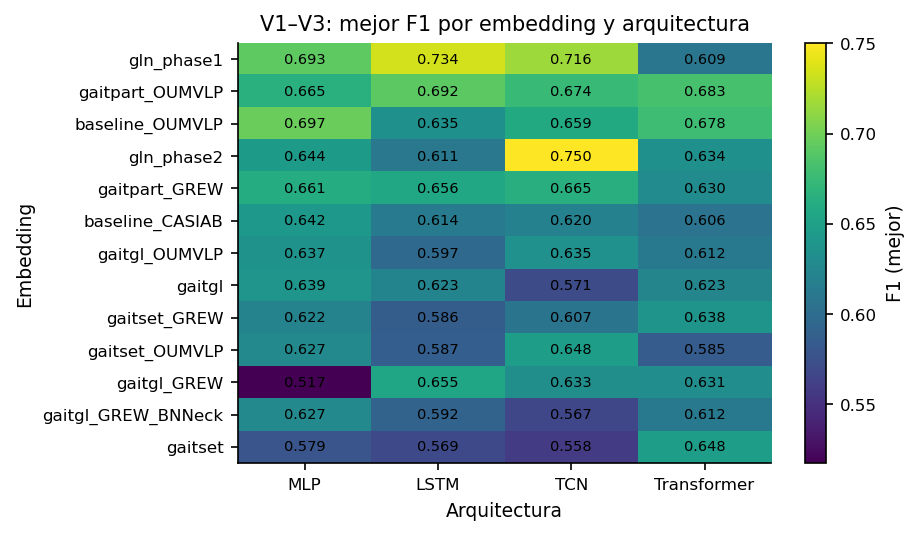

In [144]:
# HEATMAP: Mejor F1 por (embedding, arquitectura) en V1-V3

apply_paper_style()

best_em_mod = best_rows(df_v123, ["target_embedding", "model"], METRIC)

pv = best_em_mod.pivot(index="target_embedding", columns="model", values=METRIC)

cols = [c for c in MODEL_ORDER if c in pv.columns]
pv = pv[cols]

pv = pv.loc[pv.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(6.2, max(2.8, 0.28 * len(pv))))
im = ax.imshow(pv.values, aspect="auto")

ax.set_title("V1–V3: mejor F1 por embedding y arquitectura")
ax.set_xlabel("Arquitectura")
ax.set_ylabel("Embedding")

ax.set_xticks(np.arange(pv.shape[1]))
ax.set_xticklabels(pv.columns, rotation=0)

ax.set_yticks(np.arange(pv.shape[0]))
ax.set_yticklabels(pv.index)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("F1 (mejor)")

# (opcional) escribir valores dentro de la celda
for i in range(pv.shape[0]):
    for j in range(pv.shape[1]):
        val = pv.values[i, j]
        if np.isfinite(val):
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

# plt.savefig("fig_v123_heatmap_bestf1.pdf", bbox_inches="tight")


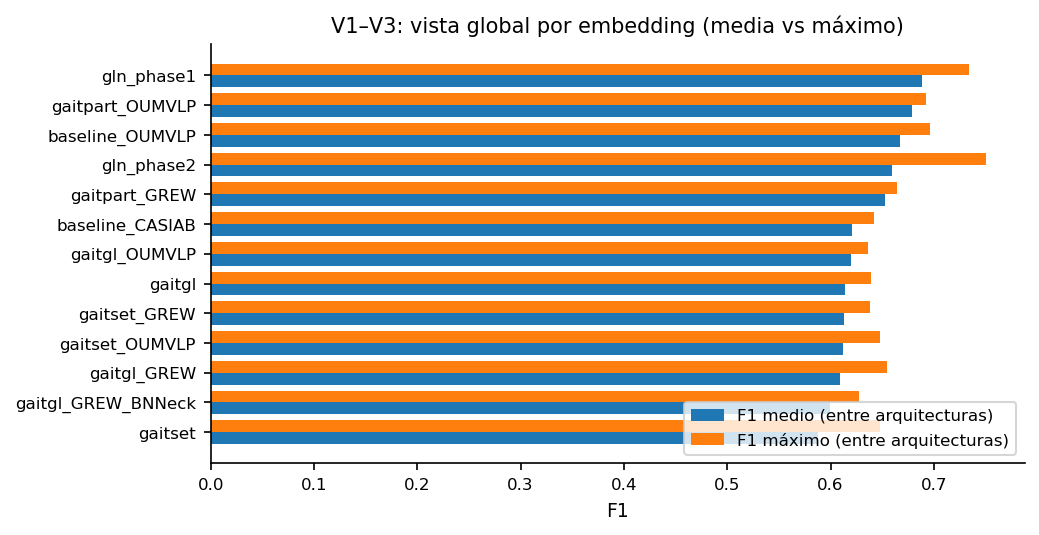

In [145]:
# BARH: Vista global por embedding (media vs máximo entre arquitecturas) en V1–V3

apply_paper_style()

best_em_mod = best_rows(df_v123, ["target_embedding", "model"], METRIC)

stats = (best_em_mod.groupby("target_embedding")[METRIC]
         .agg(f1_mean="mean", f1_max="max")
         .sort_values("f1_mean", ascending=True))

y = np.arange(len(stats))
h = 0.40

fig, ax = plt.subplots(figsize=(7.0, max(3.0, 0.28 * len(stats))))
ax.barh(y - h/2, stats["f1_mean"].values, height=h, label="F1 medio (entre arquitecturas)")
ax.barh(y + h/2, stats["f1_max"].values,  height=h, label="F1 máximo (entre arquitecturas)")

ax.set_yticks(y)
ax.set_yticklabels(stats.index)
ax.set_xlabel("F1")
ax.set_title("V1–V3: vista global por embedding (media vs máximo)")

ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# plt.savefig("fig_v123_global_por_embedding.pdf", bbox_inches="tight")


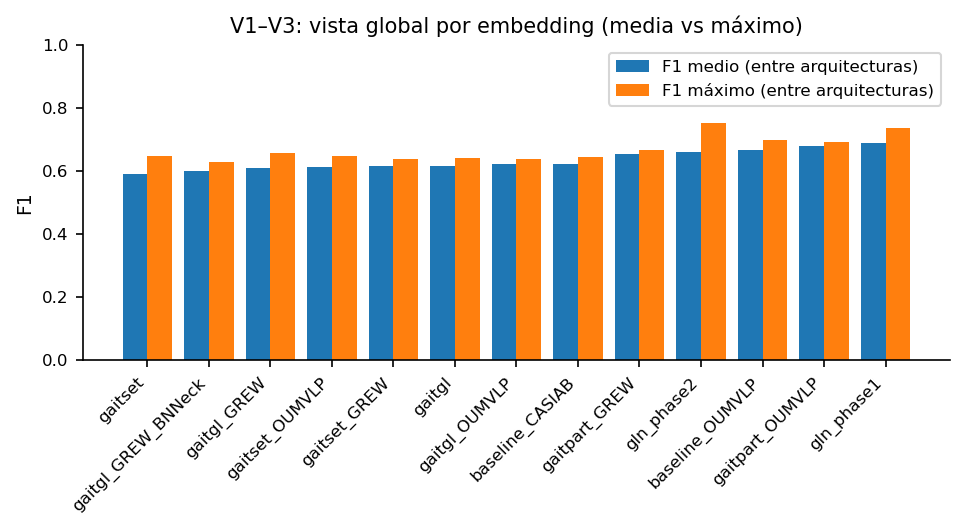

In [146]:
# BARH (ejes “al revés”) + eje F1 desde 0.5

apply_paper_style()

best_em_mod = best_rows(df_v123, ["target_embedding", "model"], METRIC)

stats = (best_em_mod.groupby("target_embedding")[METRIC]
         .agg(f1_mean="mean", f1_max="max")
         .sort_values("f1_mean", ascending=True))

x = np.arange(len(stats))
h = 0.40

fig, ax = plt.subplots(figsize=(max(6.5, 0.45 * len(stats)), 3.6))

# barras verticales (cambiamos barh -> bar)
ax.bar(x - h/2, stats["f1_mean"].values, width=h, label="F1 medio (entre arquitecturas)")
ax.bar(x + h/2, stats["f1_max"].values,  width=h, label="F1 máximo (entre arquitecturas)")

ax.set_xticks(x)
ax.set_xticklabels(stats.index, rotation=45, ha="right")

ax.set_ylabel("F1")
ax.set_title("V1–V3: vista global por embedding (media vs máximo)")

# que el F1 empiece en 0.5
ax.set_ylim(0, 1)

ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# plt.savefig("fig_v123_global_por_embedding_bar.pdf", bbox_inches="tight")


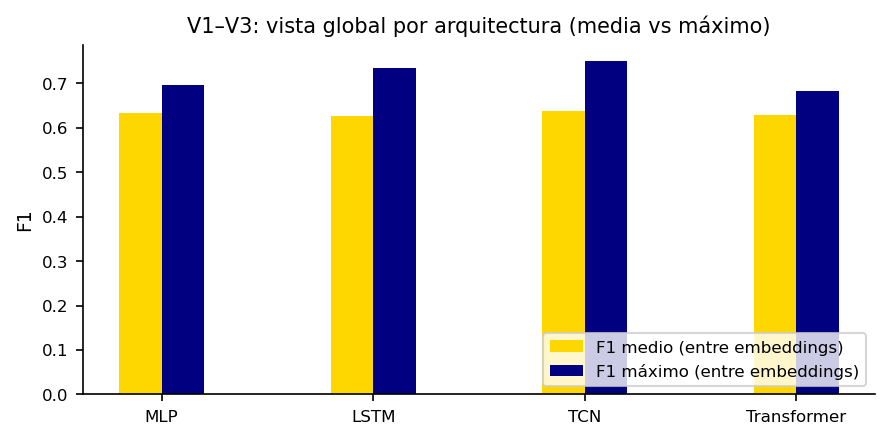

In [147]:

# BARS: Vista global por arquitectura (media vs máximo entre embeddings) en V1–V3

apply_paper_style()

best_em_mod = best_rows(df_v123, ["target_embedding", "model"], METRIC)

stats_m = (best_em_mod.groupby("model")[METRIC]
           .agg(f1_mean="mean", f1_max="max"))

# reorden
stats_m = stats_m.loc[[m for m in MODEL_ORDER if m in stats_m.index]]

x = np.arange(len(stats_m))
w = 0.2

fig, ax = plt.subplots(figsize=(6.0, 3.0))
ax.bar(x - w/2, stats_m["f1_mean"].values, width=w, label="F1 medio (entre embeddings)", color="gold")
ax.bar(x + w/2, stats_m["f1_max"].values,  width=w, label="F1 máximo (entre embeddings)", color="navy")

ax.set_xticks(x)
ax.set_xticklabels(stats_m.index)
ax.set_ylabel("F1")
ax.set_title("V1–V3: vista global por arquitectura (media vs máximo)")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

# plt.savefig("fig_v123_global_por_arquitectura.pdf", bbox_inches="tight")


C:\Users\grial_h2phao1\AppData\Local\Temp\ipykernel_22608\2220220937.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showfliers=False)


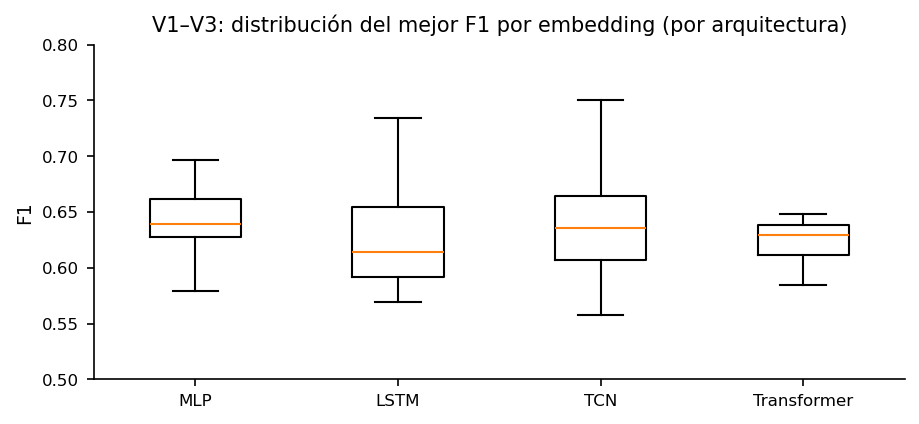

In [148]:

# BOXPLOT: distribución del mejor F1 por embedding (por arquitectura)

apply_paper_style()

best_em_mod = best_rows(df_v123, ["target_embedding", "model"], METRIC)

order = ["MLP","LSTM","TCN","Transformer"]
data = [best_em_mod.loc[best_em_mod["model"] == m, METRIC].dropna().values for m in order]

fig, ax = plt.subplots(figsize=(6.2, 2.9))
ax.boxplot(data, labels=order, showfliers=False)
ax.set_ylabel("F1")
ax.set_title("V1–V3: distribución del mejor F1 por embedding (por arquitectura)")
ax.set_ylim(0.5, 0.8)
plt.tight_layout()
plt.show()
